# **Image Captioning with ViT, Attention and LSTM**

This project explores how a model turns visual features into a sequence of words. A **custom image captioning model** learns from `Flickr8k`, then its captions are compared with those from a **pre-trained BLIP model**.

# **Project Overview**

The experiment uses the `Flickr8k` [dataset](https://www.kaggle.com/datasets/adityajn105/flickr8k), with separate **training, validation,** and **test** sets. The custom model follows an **Encoder-Decoder + Attention** structure: a pre-trained *Vision Transformer* extracts spatial features, an attention layer weights those features, and an LSTM decoder generates the caption. Fine-tuning the encoder's last four blocks adapts its features to the captioning task.

`Flickr8k` contains roughly **8,000 images**, each paired with **5 captions**. The dataset keeps the captions grouped by image. Training samples one reference per image, while evaluation retains **all matching reference captions** for `BLEU` scoring.

The vocabulary is built from training captions and excludes words below a frequency threshold. Special tokens represent sentence boundaries, padding and words outside the vocabulary.

# **Experimental Goals**

- Study whether the model learns useful image-to-text associations by following **loss curves**, generated captions and evaluation metrics.
- Use the **training** split for weight updates, **validation** for monitoring and checkpoint selection, and the held-out **test** split for final evaluation.
- Connect numerical results with **visual examples** of captions and attention maps.
- Compare the custom model with **BLIP**, recognizing their different pre-training histories.

# **Experiment Design**

- Data Preparation and Visualization:
  - Split images into **training, validation and test sets**.
  - Inspect **sample images with their original captions**.
  - Inspect **tokenized captions** and padded batches to check preprocessing.

- Model Training and Performance Monitoring:
  - Train an **Encoder-Decoder + Attention** model.
  - Track **training and validation loss** with plots.
  - Monitor **BLEU-1, BLEU-2, BLEU-3 and BLEU-4** using greedy validation decoding.

- Generalization and Checkpointing:
  - Apply **early stopping** when validation loss stops improving.
  - Use **dropout and weight decay** as regularization.
  - Use label-smoothed cross-entropy, with other loss choices documented for comparison.
  - Save the **best-performing model** according to validation loss, plus checkpoints for resuming training.

- Model Comparison:
  - Evaluate both models on the **same held-out test images**.
  - Compare **generated captions** with the reference captions.
  - Compute **BLEU scores** using all available references for each image.
  - Examine each model's strengths and limitations through scores and visual examples.

- Experiment Tracking:
  - Record **training progress**, losses and caption metrics in the notebook.
  - Plots and metrics are displayed locally; checkpoints retain training history.


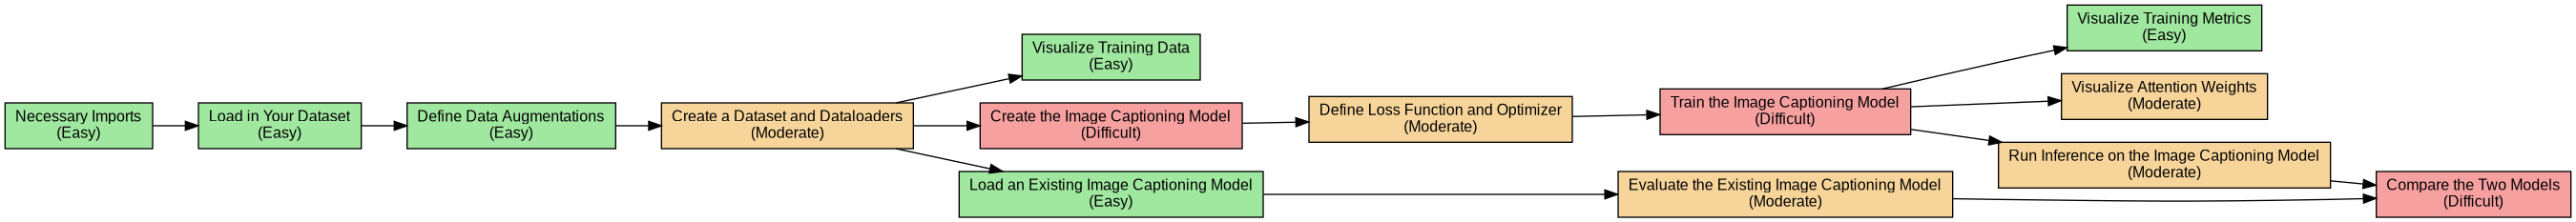

In [1]:
# @title Image Captioning Tasks
# %%capture flowchart_output
# HIDDEN CELL
from graphviz import Digraph
from IPython.display import Image as IMG

def create_flowchart(output_filename='flowchart'):
    dot = Digraph(name='Simplified Object Detection', format='png')
    dot.attr(rankdir='LR')
    dot.attr('node', shape='box', style='filled', fontsize='12', fontname='Arial')

    dot.node('Imports', 'Necessary Imports\n(Easy)', fillcolor='#A0E7A0')

    dot.node('LoadData', 'Load in Your Dataset\n(Easy)', fillcolor='#A0E7A0')

    dot.node('AugmentData', 'Define Data Augmentations\n(Easy)', fillcolor='#A0E7A0')

    dot.node('DatasetDataloader', 'Create a Dataset and Dataloaders\n(Moderate)', fillcolor='#F6D49A')

    dot.node('VisualizeSample', 'Visualize Training Data\n(Easy)', fillcolor='#A0E7A0')
    dot.node('CreateModel', 'Create the Image Captioning Model\n(Difficult)', fillcolor='#F6A0A0')

    dot.node('Hyperparameters', 'Define Loss Function and Optimizer\n(Moderate)', fillcolor='#F6D49A')

    dot.node('TrainModel', 'Train the Image Captioning Model\n(Difficult)', fillcolor='#F6A0A0')

    dot.node('VisualizeTrain', 'Visualize Training Metrics\n(Easy)', fillcolor='#A0E7A0')
    dot.node('VisualizeAtt', 'Visualize Attention Weights\n(Moderate)', fillcolor='#F6D49A')
    dot.node('RunInference', 'Run Inference on the Image Captioning Model\n(Moderate)', fillcolor='#F6D49A')

    dot.node('LoadModel', 'Load an Existing Image Captioning Model\n(Easy)', fillcolor='#A0E7A0')

    dot.node('EvaluateModel', 'Evaluate the Existing Image Captioning Model\n(Moderate)', fillcolor='#F6D49A')

    dot.node('Comparison', 'Compare the Two Models\n(Difficult)', fillcolor='#F6A0A0')

    # Edges
    dot.edge('Imports', 'LoadData')

    dot.edge('LoadData', 'AugmentData')

    dot.edge('AugmentData', 'DatasetDataloader')

    dot.edge('DatasetDataloader', 'CreateModel')
    dot.edge('DatasetDataloader', 'VisualizeSample')

    dot.edge('CreateModel', 'Hyperparameters')
    dot.edge('Hyperparameters', 'TrainModel')
    dot.edge('TrainModel', 'VisualizeTrain')
    dot.edge('TrainModel', 'VisualizeAtt')
    dot.edge('TrainModel', 'RunInference')

    dot.edge('DatasetDataloader', 'LoadModel')
    dot.edge('LoadModel', 'EvaluateModel')
    dot.edge('RunInference', 'Comparison')
    dot.edge('EvaluateModel', 'Comparison')

    dot.render(output_filename, view=False)

create_flowchart('assignment1_flowchart')
IMG('assignment1_flowchart.png')

The notebook follows the complete image-captioning workflow:

- `environment setup and imports`
- `data loading and image-level splits`
- `image augmentation and preprocessing`
- `vocabulary, dataset and dataloaders`
- `training-data visualization`
- `ViT encoder, attention and LSTM decoder`
- `loss function and optimizer`
- `training, validation and checkpointing`
- `test-set inference`
- `comparison with BLIP`
- `caption and attention visualization`

Each stage includes the implementation and an explanation of the choices behind it.

## **Experiment Scope**

This is a study of the full image-captioning pipeline, from paired image-text data to model interpretation. The aim is to understand training behavior and caption quality rather than claim state-of-the-art performance.

- Training and validation curves provide evidence of learning and possible overfitting.
- The test split is reserved for final evaluation.
- Generated captions are inspected alongside their references and images.
- Results belong to the configuration and completed run that produced them.

## **Notebook Usage**

The notebook can run in **Google Colab** or a compatible Jupyter environment. Cells follow their dependency order. A GPU is appropriate for training the captioning model.

Drive-backed checkpoints support recovery from Colab runtime resets when Drive mounts successfully. Saving the executed `.ipynb` preserves the plots, captions and metrics for later analysis.


**Author:** Robert Ouko Oyombe

**Source:** Built on the course assignment notebook by Tamás Takács and
Imre Molnár, Department of Artificial Intelligence, Eötvös Loránd University.


## **0. Necessary Imports**
The experiment uses **PyTorch** for model construction and training, with supporting packages for image preprocessing, caption tokenization, evaluation and visualization.

In [2]:
# Necessary Imports Imports:

# Core Python Libraries
import os # File/directory operations
import random # Randomness for fun and data augmentation
import warnings # Warning control (keep it clean!)

# Data Handling & Visualization
import numpy as np # Numerical operations (arrays, tensors)
import pandas as pd # Dataframes for caption handling
import matplotlib.pyplot as plt # Plotting and visualizations

# PyTorch Core
import torch # Main deep learning framework
import torch.nn as nn # Building blocks for models
import torch.optim as optim # Optimization algorithms
import torch.nn.functional as F # Functional tools for layers

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader # Dataset and data loading
from torch.nn.utils.rnn import pad_sequence # Padding for batching sequences

# Computer Vision
import torchvision # Vision models & tools
from torchvision import transforms # Image transformations
from torchvision.models import resnet101 # Powerful pretrained ResNet model

# Natural Language Processing (NLP)
import nltk # Natural Language Toolkit
from nltk.tokenize import word_tokenize # Word tokenization
from nltk.translate.bleu_score import corpus_bleu # BLEU score for evaluation
from collections import Counter # Word frequency counter

# Utilities
from tqdm import tqdm           # ⏳ Beautiful progress bars
from PIL import Image # Image loading and manipulation

# Configuration and Setup
warnings.filterwarnings('ignore') # Silence annoying warnings for cleaner outputs
nltk.download('punkt', quiet=True) # Download tokenizers silently

# Device Setup (GPU/CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ")


Using device: cuda:0 


## **1. Data Loading Process**

The experiment uses the [Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k) dataset, which contains **captions/descriptions** of different images.

<img src="https://user-images.githubusercontent.com/38347541/56469847-9faa0780-645c-11e9-822a-11a15bb56f5b.png" alt="1" border="0">

The notebook reuses **Images/** and **captions.txt** from `DATA_DIR`. By default, this is the project's ignored `data/flickr8k` folder. Set `FLICKR8K_DATA_DIR` to point to another extracted copy before running setup.

When data are absent, setup downloads **version 1** directly from Kaggle without Colab Secrets or API keys. Archive and file fingerprints verify the exact dataset. On a remote Colab runtime, Windows paths are unavailable; the default runtime path downloads its own copy, or an accessible transferred copy can be selected.


In [3]:
# Dataset location: set FLICKR8K_DATA_DIR to reuse an existing extracted copy.
# The directory must contain Images/ and captions.txt.
from pathlib import Path
import os
import json
import hashlib
import urllib.request
import shutil
import zipfile

_here = Path.cwd()
if _here.name == 'notebooks':
    PROJECT_DIR = _here.parent
elif (_here / 'notebooks').is_dir():
    PROJECT_DIR = _here
elif Path('/content').is_dir():
    PROJECT_DIR = Path('/content/image-captioning-flickr8k')
else:
    PROJECT_DIR = _here
DATA_DIR = Path(os.environ.get('FLICKR8K_DATA_DIR', str(PROJECT_DIR / 'data/flickr8k'))).expanduser().resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATASET_URL = 'https://www.kaggle.com/api/v1/datasets/download/adityajn105/flickr8k?datasetVersionNumber=1'
ARCHIVE_SHA256 = '0677f83ccb736b08e73ddd1219ba1ba12bc72a8742a71df4edaaaa4abc64d42b'
print(f'Dataset folder: {DATA_DIR}')


Dataset folder: /content/image-captioning-flickr8k/data/flickr8k


In [4]:
# Inspect only the configured dataset location; no secrets are requested.
print(f"Images present: {(DATA_DIR / 'Images').is_dir()}")
print(f"Captions present: {(DATA_DIR / 'captions.txt').is_file()}")
print(f"Archive present: {(DATA_DIR / 'flickr8k.zip').is_file()}")


Images present: False
Captions present: False
Archive present: False


In [5]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def prepare_flickr8k(data_dir):
    data_dir = Path(data_dir).resolve()
    if (data_dir / 'Images').is_dir() and (data_dir / 'captions.txt').is_file():
        print('Reusing extracted data; content verification follows.')
        return
    archive = data_dir / 'flickr8k.zip'
    if not archive.is_file():
        partial = data_dir / 'flickr8k.zip.part'
        print('Downloading Flickr8k version 1 from Kaggle (about 1.1 GB).')
        request = urllib.request.Request(DATASET_URL, headers={'User-Agent': 'Mozilla/5.0'})
        try:
            with urllib.request.urlopen(request, timeout=120) as response, partial.open('wb') as out:
                total = int(response.headers.get('Content-Length', 0))
                copied = 0
                reported = 0
                while True:
                    block = response.read(4 * 1024 * 1024)
                    if not block:
                        break
                    out.write(block)
                    copied += len(block)
                    if copied - reported >= 100 * 1024 * 1024:
                        print(f'Downloaded {copied / 1024**2:.0f} MB' +
                              (f' / {total / 1024**2:.0f} MB' if total else ''))
                        reported = copied
        except Exception as exc:
            raise RuntimeError(
                'Dataset download failed. Download Flickr8k version 1 from the source page, '
                'extract Images/ and captions.txt into DATA_DIR, then rerun setup. '
                'A Windows folder must first be transferred to the remote Colab runtime.'
            ) from exc
        if file_sha256(partial) != ARCHIVE_SHA256:
            raise ValueError('Downloaded archive checksum differs from the pinned dataset; extraction stopped.')
        partial.replace(archive)
    if file_sha256(archive) != ARCHIVE_SHA256:
        raise ValueError('Archive checksum mismatch; extraction stopped.')
    with zipfile.ZipFile(archive) as bundle:
        for member in bundle.infolist():
            if not (data_dir / member.filename).resolve().is_relative_to(data_dir):
                raise ValueError('Archive contains an unsafe path.')
        bundle.extractall(data_dir)
    print('Archive verified and extracted.')

prepare_flickr8k(DATA_DIR)


Downloaded 100 MB / 1061 MB
Downloaded 200 MB / 1061 MB
Downloaded 300 MB / 1061 MB
Downloaded 400 MB / 1061 MB
Downloaded 500 MB / 1061 MB
Downloaded 600 MB / 1061 MB
Downloaded 700 MB / 1061 MB
Downloaded 800 MB / 1061 MB
Downloaded 900 MB / 1061 MB
Downloaded 1000 MB / 1061 MB
Archive verified and extracted.


In [6]:
# Verify every image and the caption file, including pre-existing copies.
# This prevents silently accepting a partial or modified dataset.
# Leave empty to record the hash on this run; paste the printed value back in
# to pin the dataset for later runs. The archive checksum in the previous cell
# already verified the download, so this guards against local edits afterwards.
EXPECTED_CONTENT_SHA256 = ''
records = []
for file in sorted((DATA_DIR / 'Images').glob('*')):
    if file.is_file():
        records.append((file.relative_to(DATA_DIR).as_posix(), file_sha256(file)))
records.append(('captions.txt', file_sha256(DATA_DIR / 'captions.txt')))
records.sort()
DATASET_CONTENT_SHA256 = hashlib.sha256(
    ''.join(name + ' ' + digest + '\n' for name, digest in records).encode()
).hexdigest()
if EXPECTED_CONTENT_SHA256 and DATASET_CONTENT_SHA256 != EXPECTED_CONTENT_SHA256:
    raise ValueError('Dataset content differs from pinned Flickr8k v1. Check DATA_DIR for missing or altered files.')
print(f'Verified {len(records) - 1} images and captions.txt.')
if not EXPECTED_CONTENT_SHA256:
    print(f'Content hash for this dataset: {DATASET_CONTENT_SHA256}')


Verified 8091 images and captions.txt.
Content hash for this dataset: e1049079fe669085dd9d31755cd9fa6e7a9d9fbf6402ab8f7c61b415a1dbf4b9


In [7]:
# A small local record accompanies the downloaded data; no credentials are stored.
provenance = {
    'source': 'https://www.kaggle.com/datasets/adityajn105/flickr8k',
    'version': 1,
    'archive_sha256': ARCHIVE_SHA256,
    'content_sha256': DATASET_CONTENT_SHA256,
}
(DATA_DIR / 'dataset-provenance.json').write_text(json.dumps(provenance, indent=2) + '\n', encoding='utf-8')
print('Data source: adityajn105/flickr8k, version 1')
print('Data are stored outside Git; only fingerprints and split lists are versioned.')


Data source: adityajn105/flickr8k, version 1
Data are stored outside Git; only fingerprints and split lists are versioned.


In [8]:
import os
import zipfile
import random

def load_flickr8k(data_dir):
    print("\n Setting up the Flickr8k Dataset Adventure... ")

    # Ensure the data directory exists
    os.makedirs(data_dir, exist_ok=True)
    print(f"Data directory checked/created at: {data_dir}")

    # Load captions
    captions_path = os.path.join(data_dir, 'captions.txt')
    image_captions = {}
    if os.path.exists(captions_path):
        print("Loading captions...")
        with open(captions_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    img, caption = line.strip().split(',', 1)
                    image_captions.setdefault(img, []).append(caption)
                except ValueError:
                    continue

        print(f"Captions loaded for {len(image_captions)} unique images from captions.txt.")
    else:
        raise FileNotFoundError(f"Captions file not found at {captions_path}")

    # Locate images
    images_dir = os.path.join(data_dir, 'Images')
    if not os.path.exists(images_dir):
        raise FileNotFoundError(f"Images directory not found at {images_dir}")

    # Match valid images (only .jpg/.jpeg files, exclude folders)
    all_images = [
        img for img in image_captions.keys()
        if os.path.isfile(os.path.join(images_dir, img))  # Ensure it's a file, not a folder
        and img.lower().endswith(('.jpg', '.jpeg'))       # Ensure it has a valid image extension
    ]

    # Debugging: Report the number of valid images
    print(f"Found {len(all_images)} valid images in the Images directory.")

    if not all_images:
        raise ValueError("No valid images found in the dataset!")

    # Update image_captions to only include valid images
    image_captions = {img: captions for img, captions in image_captions.items() if img in all_images}
    print(f"Updated captions to include only valid images ({len(image_captions)}).")

    # Shuffle for randomness
    random.Random(42).shuffle(all_images)

    # Split into train/val/test
    train_split = int(0.7 * len(all_images))
    val_split = int(0.85 * len(all_images))

    train_images = all_images[:train_split]
    val_images = all_images[train_split:val_split]
    test_images = all_images[val_split:]

    # Save exact image identities, preserving the original seeded 70/15/15 split.
    splits = {'train': train_images, 'validation': val_images, 'test': test_images}
    split_text = json.dumps(splits, indent=2) + '\n'
    split_path = Path(data_dir) / 'splits.json'
    if split_path.exists() and json.loads(split_path.read_text(encoding='utf-8')) != splits:
        raise ValueError('Existing split lists differ from this dataset; refusing to overwrite them.')
    split_path.write_text(split_text, encoding='utf-8')

    # Assemble dataset splits
    train_data = [(os.path.join(images_dir, img), image_captions[img]) for img in train_images]
    val_data = [(os.path.join(images_dir, img), image_captions[img]) for img in val_images]
    test_data = [(os.path.join(images_dir, img), image_captions[img]) for img in test_images]

    # Final confirmation of dataset size
    print(f"Total valid images: {len(all_images)}")
    print(f"Training samples: {len(train_data)}")
    print(f"Validation samples: {len(val_data)}")
    print(f"Test samples: {len(test_data)}")

    return train_data, val_data, test_data

# Load the dataset!
print("Let the magic begin!\n")
train_data, val_data, test_data = load_flickr8k(DATA_DIR)

# Summarize the results
if train_data:
    print("\n Dataset loaded successfully! ")
else:
    print("Failed to load dataset. ")


Let the magic begin!


 Setting up the Flickr8k Dataset Adventure... 
Data directory checked/created at: /content/image-captioning-flickr8k/data/flickr8k
Loading captions...
Captions loaded for 8092 unique images from captions.txt.
Found 8091 valid images in the Images directory.
Updated captions to include only valid images (8091).
Total valid images: 8091
Training samples: 5663
Validation samples: 1214
Test samples: 1214

 Dataset loaded successfully! 


```python
# Prepare Flickr8k from a verified local or runtime dataset folder.
# Reuse existing data or download the pinned public archive without credentials.
# Read captions.txt and map image filenames to their reference captions.
# Preserve the seeded image-level train/validation/test split and save its image lists.
```


## **2. Defining Augmentations**

When applying **augmentations** to the `Flickr8k` dataset, it is important to note that these transformations should be applied **only to the images** and not to the captions.

The **image preprocessing pipeline** combines:
- A **normalization step** to scale pixel values appropriately.
- A **tensor conversion step** to transform images into tensors for model compatibility.
- Training **augmentations**, including random cropping, flipping and color jittering, to introduce visual variation.

The two pipeline interfaces are shown below; the following code cell defines their transformations.

```python
train_transforms = transforms.Compose([
            # Add Augmentations
])

test_transforms = transforms.Compose([
            # Add Augmentations
])
```

In [9]:
# Setting up image transformations...

from torchvision import transforms

# Define training augmentations
print("Preparing training transformations...")
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224), # Random crop and resize to 224x224
    transforms.RandomHorizontalFlip(), # Random horizontal flip
    transforms.ColorJitter(# Random color adjustments
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(# Slight rotations and translations
        degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(), # Convert to tensor
    transforms.Normalize(# Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(# Randomly erase parts for robustness
        p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
    transforms.RandomGrayscale(p=0.1), # Sometimes turn to grayscale
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 5.0)) # Apply a soft blur
])

# Define testing augmentations (simple and clean)
print("Preparing testing transformations...")
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to 224x224
    transforms.ToTensor(), # Convert to tensor
    transforms.Normalize(# Normalize
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

print("Transformations are ready!")


Preparing training transformations...
Preparing testing transformations...
Transformations are ready!


```python
# Image transformations using the torchvision.transforms module.
# Useful for preprocessing images in a computer vision tasks, (in this case image captioning).
# Creating two transformation pipelines: one for training and one for testing.
# Important to improve model generalization and standardized preprocessing
(for testing to ensure fair evaluation.)
# Why? -> Improved Generalization, Prevent Overfitting, Increased Data Size
(Training: heavy augmentation - creates variety & robustness, mimicking real-world variability.)
(Minimal transformations - Evaluate the model on clean, standardized inputs
no randomness, ensures fair and reproducible results.)
```


## **3. Creating Datasets and Dataloaders**

The custom **PyTorch** `Dataset` pairs each image with its captions and returns **tokenized captions** alongside the image tensor.

Special tokens make sentence boundaries and vocabulary limits explicit:

- `sos` (Start of Sentence)
- `eos` (End of Sentence)
- `unk` (Unknown Token) for words outside the vocabulary
- `pad` for equal-length batches

The **Vocabulary class** assigns word indices using training captions. Words must appear **at least 5 times** to enter the vocabulary; rarer words map to `unk`. Building this mapping on the training split keeps evaluation captions out of vocabulary construction.

The **DataLoaders** use batches of 32 images:

- **Training DataLoader:** `shuffle=True`, with random reference-caption selection.
- **Validation and Test DataLoaders:** `shuffle=False`, with a fixed reference for loss calculation and all references retained for BLEU.

> **Note**: Captions have **different lengths**. Padding allows them to share a batch, and padded positions are excluded from the training objective.

The dataset interface separates construction, length and sample retrieval:

```python
class FlickrDataset(Dataset):
    def __init__(self,):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        raise NotImplementedError
```


Mounted at /content/drive
Drive mounted: /content/drive/MyDrive/image-captioning-flickr8k
Checkpoints: /content/drive/MyDrive/image-captioning-flickr8k/checkpoints
Random seed set to 42


Building Vocabulary: 100%|██████████| 28315/28315 [00:01<00:00, 15934.52it/s]



=== DataLoader Sanity Check ===
Batch shapes:
Images: torch.Size([32, 3, 224, 224])
Captions: torch.Size([32, 19])
Sample caption: a dog in shallow water .

--- Dataset Statistics ---
Train dataset size: 5663
Validation dataset size: 1214
Test dataset size: 1214
Vocabulary size: 2512

--- Debug: Showing 5 different samples each run ---

Sample 1  - Image path: /content/image-captioning-flickr8k/data/flickr8k/Images/3109124656_626b596d5e.jpg
  1. A couple sits on a floral couch while an older woman in the background smiles .
  2. A couple sitting together on a flowered sofa with an older woman .
  3. A man and woman have their arms around each other while an older woman in orange sits next to them .
  4. A man and woman hug on a couch while another woman smiles .
  5. A man and woman pose on a couch .


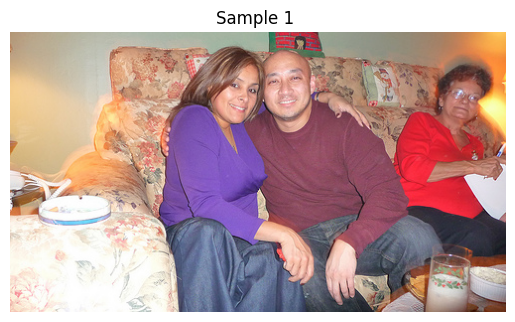


Sample 2  - Image path: /content/image-captioning-flickr8k/data/flickr8k/Images/421706022_1ddb6a7a78.jpg
  1. A man in black stands between two huge soft toys at a fairground .
  2. a police officer in the middle of a parade
  3. A police officer keeps watch a parade .
  4. A police officer stands between dragons in a Chinese New Year celebration .
  5. This policeman is standing in front of a ride at a carnival .


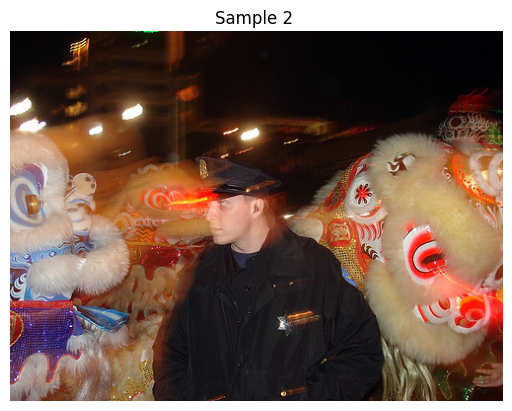


Sample 3  - Image path: /content/image-captioning-flickr8k/data/flickr8k/Images/2920969723_83918fe909.jpg
  1. A boy rides his skateboard across a pipe on a building .
  2. "A child on a skateboard flies through the air , alongside a building ."
  3. A skateboarder grinds along a pipe beneath a fire escape .
  4. A skateboarder jumping in front of a building .
  5. A skateboarder rides down a city street .


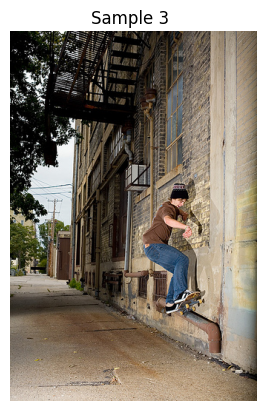


Sample 4  - Image path: /content/image-captioning-flickr8k/data/flickr8k/Images/2281075738_230892b241.jpg
  1. One black dog chases another on grass nearby a road that was recently snowed on .
  2. Two black dogs are playing in a grassy plain .
  3. Two black dogs chase each other on grass .
  4. Two black dogs running
  5. Two black dogs running on grass .


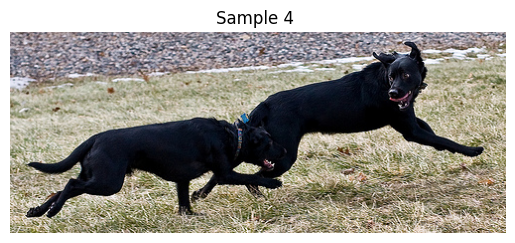


Sample 5  - Image path: /content/image-captioning-flickr8k/data/flickr8k/Images/2574230252_f5a1382dd4.jpg
  1. A black dog splashes through greenish water .
  2. A black dog walking through splashing water in a rocky creek .
  3. A brown dog walks through a shallow stream .
  4. A greenish dog runs through the water by several large rocks .
  5. The dog walks in the shallow water .


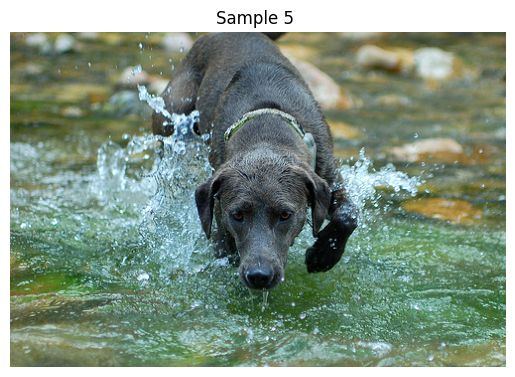


--- Sample Batch ---
Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 22])
  1. Original: The buildings are brown and the sky is blue .
Decoded: the buildings are brown and the sky is blue .
  2. Original: The man wearing knee protectors swings a cricket club .
Decoded: man wearing knee <unk> swings a cricket club .


In [10]:
import os
import importlib.util
from pathlib import Path
import random
import time
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from tqdm import tqdm

# -------------------------- NLTK Downloads --------------------------
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# -------------------------- Utility: Colorize Printing --------------------------
def colorize(text, color='blue'):
    colors = {
        'blue': '\033[94m', 'green': '\033[92m',
        'yellow': '\033[93m', 'red': '\033[91m',
        'end': '\033[0m'
    }
    return colors.get(color, '') + text + colors['end']

# -------------------------- Runtime and checkpoints --------------------------
# Installed, not imported: the VS Code Colab extension never imports it.
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False

DRIVE_DIR = None
if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount('/content/drive')
        DRIVE_DIR = Path('/content/drive/MyDrive/image-captioning-flickr8k')
        DRIVE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Drive mounted: {DRIVE_DIR}")
    except Exception as exc:
        print(f"Drive not mounted ({type(exc).__name__}). Using runtime-local paths.")

# The trainer reads this.
CHECKPOINT_DIR = DRIVE_DIR / 'checkpoints' if DRIVE_DIR else Path('checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Checkpoints: {CHECKPOINT_DIR}")

# Workers hide JPEG decoding behind GPU work. Windows spawns and cannot
# unpickle a notebook Dataset, so local runs stay single-process.
NUM_WORKERS = 2 if IN_COLAB else 0
# Matches the training config. Fine-tuning the encoder needs the smaller batch
# to fit in memory.
BATCH_SIZE = 32
PIN_MEMORY = torch.cuda.is_available()

# -------------------------- Seed --------------------------
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(colorize(f"Random seed set to {seed}", 'yellow'))

set_seed(42)

# -------------------------- Transforms --------------------------
# defined elsewhere
train_transforms = train_transforms
test_transforms = test_transforms

# -------------------------- Vocabulary --------------------------
class Vocabulary:
    def __init__(self, freq_threshold=5, dropout_prob=0.1):
        self.freq_threshold = freq_threshold
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.counter = Counter()
        self.vocab_size = 4
        self.dropout_prob = dropout_prob

    def build_vocab(self, captions):
        for caption in tqdm(captions, desc=colorize("Building Vocabulary", 'green')):
            self.counter.update(word_tokenize(caption.lower()))
        for word, freq in self.counter.items():
            if freq >= self.freq_threshold and word not in self.word2idx:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

    def tokenize(self, caption, max_len=30, apply_dropout=True):
        tokens = word_tokenize(caption.lower())
        tokens = ["<sos>"] + tokens[:max_len-2] + ["<eos>"]
        # Dropout is a training regulariser; it must not touch eval targets.
        processed_tokens = [token for token in tokens if token in ["<sos>", "<eos>", "<unk>"] or not apply_dropout or random.random() > self.dropout_prob]
        return [self.word2idx.get(token, self.word2idx["<unk>"]) for token in processed_tokens]

    def decode_caption(self, indices):
        return ' '.join([self.idx2word.get(idx, "<unk>") for idx in indices if idx not in [0, 1, 2, 0]])

    def __len__(self):
        return self.vocab_size

# -------------------------- Dataset --------------------------
class FlickrDataset(Dataset):
    def __init__(self, data, vocab, transform=None, max_len=30, apply_dropout=False,
                 random_caption=False):
        self.transform = transform
        self.vocab = vocab
        self.max_len = max_len
        # Training split only.
        self.apply_dropout = apply_dropout
        # Training may sample a different caption each epoch; evaluation cannot,
        # or validation loss moves because the target moved.
        self.random_caption = random_caption
        self.data = [(img_path, [c for c in captions if c.strip()]) for img_path, captions in data if os.path.exists(img_path) and captions]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, captions = self.data[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
        except Exception as e:
            print(colorize(f"[Warning] Failed to load {img_path}: {e}", 'red'))
            return None
        chosen_caption = random.choice(captions) if self.random_caption else captions[0]
        caption_tokens = self.vocab.tokenize(chosen_caption, max_len=self.max_len,
                                             apply_dropout=self.apply_dropout)
        return {
            'image': image,
            'caption_tokens': torch.tensor(caption_tokens, dtype=torch.long),
            'original_caption': chosen_caption,
            # BLEU needs every reference; the training target stays the one above.
            'all_captions': list(captions),
            'image_path': img_path
        }

# -------------------------- Collate Function --------------------------
def collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    images = torch.stack([item['image'] for item in batch])
    caption_tokens = [item['caption_tokens'] for item in batch]
    padded_captions = pad_sequence(caption_tokens, batch_first=True, padding_value=0)
    lengths = torch.tensor([len(cap) for cap in caption_tokens], dtype=torch.long)
    return {
        'image': images,
        'caption_tokens': padded_captions,
        'lengths': lengths,
        'original_caption': [item['original_caption'] for item in batch],
        'all_captions': [item['all_captions'] for item in batch],
        'image_paths': [item['image_path'] for item in batch]
    }

# -------------------------- Main Code Execution --------------------------
# train_data, val_data and test_data were loaded and verified in the data section.

freq_threshold = 5
dropout_prob = 0.1
max_len = 30

all_train_captions = [cap for _, caps in train_data for cap in caps]
vocab = Vocabulary(freq_threshold=freq_threshold, dropout_prob=dropout_prob)
vocab.build_vocab(all_train_captions)

train_dataset = FlickrDataset(train_data, vocab=vocab, transform=train_transforms, max_len=max_len, apply_dropout=True, random_caption=True)
val_dataset = FlickrDataset(val_data, vocab=vocab, transform=test_transforms, max_len=max_len)
test_dataset = FlickrDataset(test_data, vocab=vocab, transform=test_transforms, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY,persistent_workers=False)
# Validation is a measurement, so it runs in a fixed order like the test split.
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY,persistent_workers=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY,persistent_workers=False)

# DL Sanity Check
print("\n\033[1;35m=== DataLoader Sanity Check ===")
test_batch = next(iter(train_loader))
print("Batch shapes:")
print(f"Images: {test_batch['image'].shape}")
print(f"Captions: {test_batch['caption_tokens'].shape}")
print(f"Sample caption: {vocab.decode_caption(test_batch['caption_tokens'][0].tolist())}")

print(colorize("\n--- Dataset Statistics ---", 'blue'))
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Vocabulary size: {len(vocab)}")

# -------------------------- Debug: Show 5 different samples each run --------------------------
print(colorize("\n--- Debug: Showing 5 different samples each run ---", 'yellow'))
debug_rng = random.Random(time.time())

emojis = ["", "", "", "", "", "", ""]
sample_indices = debug_rng.sample(range(len(train_dataset)), min(5, len(train_dataset)))

for i, idx in enumerate(sample_indices):
    img_path, captions = train_dataset.data[idx]
    emoji = debug_rng.choice(emojis)
    print(colorize(f"\nSample {i+1} {emoji} - Image path: {img_path}", 'green'))
    for j, cap in enumerate(captions):
        print(f"  {j+1}. {cap}")
    try:
        image = Image.open(img_path).convert("RGB")
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Sample {i+1} {emoji}")
        plt.show()
    except Exception as e:
        print(colorize(f"Could not display image {img_path}: {e}", 'red'))

# -------------------------- Show one sample batch --------------------------
for batch in train_loader:
    if batch is None:
        continue
    print(colorize("\n--- Sample Batch ---", 'blue'))
    print("Image batch shape:", batch['image'].shape)
    print("Caption batch shape:", batch['caption_tokens'].shape)
    for i in range(min(2, len(batch['original_caption']))):
        decoded = vocab.decode_caption(batch['caption_tokens'][i].tolist())
        print(f"  {i+1}. Original: {batch['original_caption'][i]}")
        print(f"Decoded: {decoded}")
    break  # Display only one batch


```python
# Creating a vocabulary for captions.
# Structuring image-caption pairs into a PyTorch-compatible dataset.
# Setting up data loaders for efficient batch processing.
# Providing debugging tools to verify data integrity and visualize samples.
```

## **4.1 Visualizing Training Data**

A batch of **image-caption pairs** provides a visual check of the data pipeline. The grid displays at least **8 pairs**, with **original and tokenized captions** alongside the images.

This view makes it easier to spot image-loading problems, unfamiliar tokens and preprocessing effects before training. The visualization interface is:

```python
def visualize_batch():
  raise NotImplementedError
```


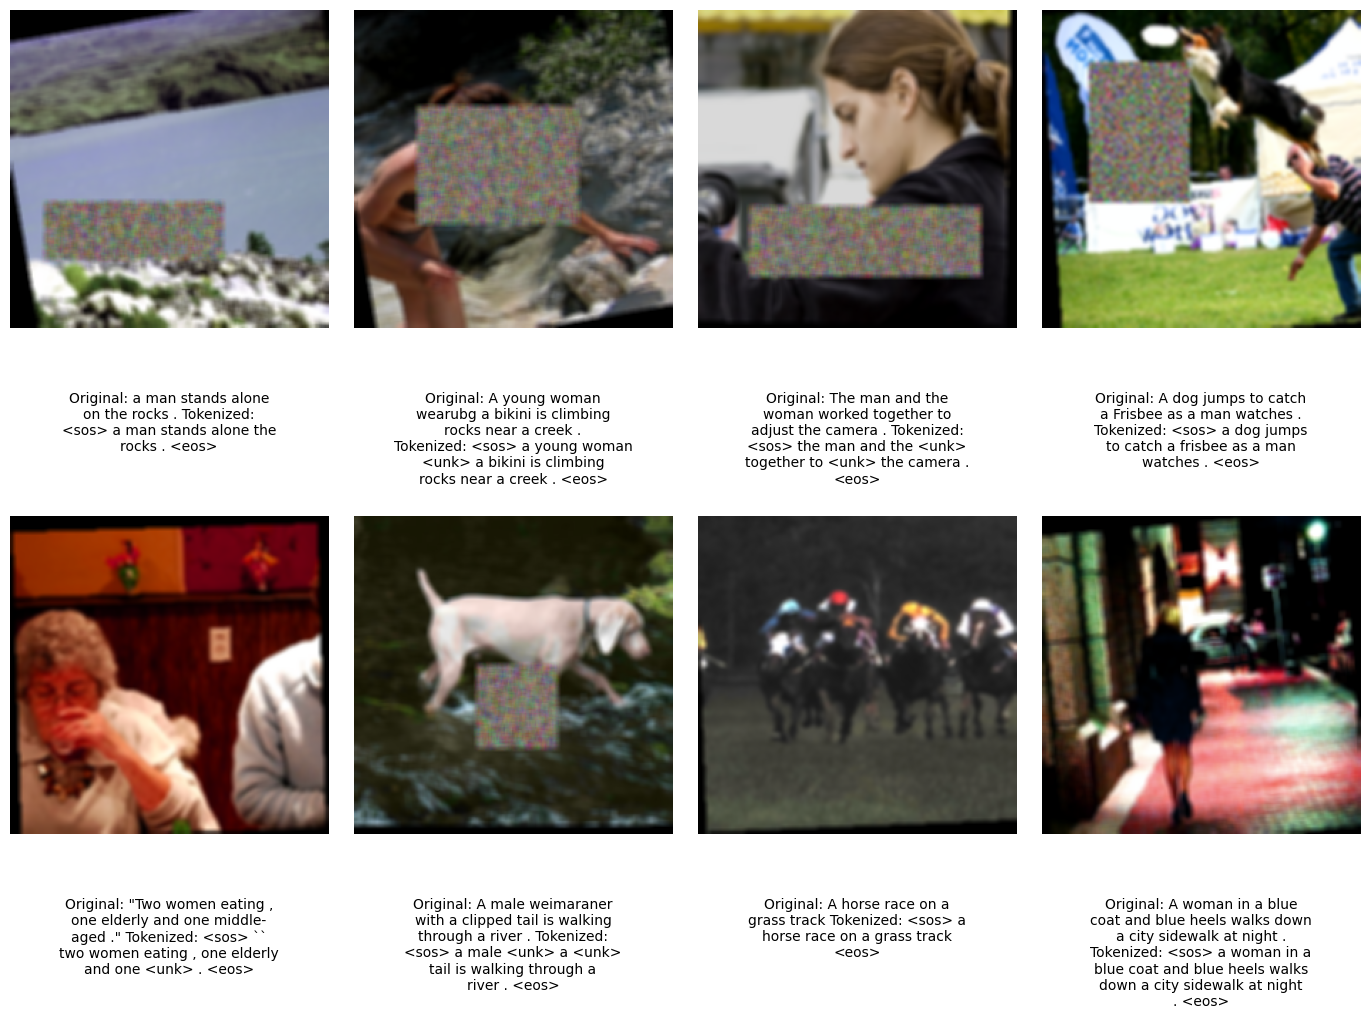

In [11]:
import matplotlib.pyplot as plt
import textwrap
import numpy as np  # For clipping values

# -------------------------- Denormalize Function --------------------------
def denormalize(image, mean, std):
    """Denormalize an image by reversing the normalization and clipping the values to the valid range."""
    for c in range(3):
        image[c] = image[c] * std[c] + mean[c]

    # Clip the values to [0, 1] range to avoid clipping warnings (we're keeping things within the "valid" zone)
    image = np.clip(image, 0, 1)

    return image

# -------------------------- Visualize Training Data --------------------------
def visualize_training_data(data_loader, vocab, mean, std, num_samples=8):
    """Visualize training data by plotting images and their corresponding captions.
    Displays both original and tokenized captions, including <sos> and <eos>.
    Just making sure we understand the "story" behind the image!
    """
    # Get a batch of data from the DataLoader
    batch = next(iter(data_loader))

    # Extract images, captions, and image paths (a little bit of everything for this fun project!)
    images = batch['image']
    captions = batch['caption_tokens']
    original_captions = batch['original_caption']
    image_paths = batch['image_paths']

    # Calculate figure dimensions - 4 images per row for 8 samples (don't worry, it's organized!)
    cols = 4 # Set to 4 images per row (perfect for a neat visual grid!)
    rows = (num_samples + cols - 1) // cols # Ceiling division (keeping things balanced!)

    # Increase figure size to fill more space for images (Let the images shine)
    fig_width = 15  # Wider to make images larger
    fig_height = 5 * rows  # Height for 2 rows with some spacing

    # Create a subplot grid to manage the layout more effectively
    fig, axs = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

    # Flatten the grid for easier access to axes (just for convenience)
    axs = axs.flatten()

    for i in range(min(num_samples, len(images))):
        ax = axs[i]

        # Denormalize the image before plotting (We want it to look pretty, right?)
        denormalized_image = denormalize(images[i].clone(), mean, std)

        # Convert tensor to numpy array for plotting (because matplotlib likes it this way)
        ax.imshow(denormalized_image.permute(1, 2, 0).numpy())  # Convert to HWC format
        ax.axis('off') # No axes around our beautiful image!

        # Get the tokenized caption and decode it back to the original caption (It’s like translating!)
        tokenized_caption = vocab.decode_caption(captions[i].tolist())
        original_caption = original_captions[i]

        # Create a better formatted caption string (keeping it neat and readable!)
        caption_text = f"Original: {original_caption}\nTokenized: <sos> {tokenized_caption} <eos>"

        # Use text wrapping for long captions (let's wrap it so no caption gets left out!)
        wrapped_text = "\n".join(textwrap.wrap(caption_text, width=30))

        # Adjust vertical placement to avoid overlap (captions should have room to breathe)
        ax.text(0.5, -0.2, wrapped_text,
                transform=ax.transAxes,
                ha='center',
                va='top',
                fontsize=10,  # Increased from 8 to 10 (bigger text = more fun!)
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))  # Semi-transparent box for readability

    # Adjust layout with more padding for captions and less space between subplots (comfort is key!)
    plt.tight_layout(pad=2.0, h_pad=4.0)  # Increased padding to ensure clearer space
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)  # Adjust margins to remove unused space
    plt.show()

# For ImageNet images (RGB channels)
mean = [0.485, 0.456, 0.406] # The magical mean values for RGB (the secret sauce)
std = [0.229, 0.224, 0.225] # The magical standard deviations (keeps everything in balance)

# Call the function to visualize the samples (Time to see our beautiful images!)
visualize_training_data(train_loader, vocab, mean, std, num_samples=8)


```python
# Visualizing training data - > verify the correctness of the dataset and preprocessing pipeline.
# Displays images alongside their original and tokenized captions
# Helps debug issues like incorrect image loading, normalization & tokenization
```

## **4.2 Creating the Image Captioning Model**

The custom **image captioning model** combines spatial image features with sequential word prediction. Its performance is later **compared with a pre-trained model**.

---

### **Encoder-Attention-Decoder Architecture**

The model follows an **Encoder-Attention-Decoder** structure with three components:

- The **Encoder** processes images to extract meaningful features. This experiment uses a **pre-trained ViT-B/16**, with its last four transformer blocks fine-tuned for captioning. A convolutional backbone such as *ResNet* is an alternative design.
- The **Attention Layer** acts as an interface between the encoder and decoder. It leverages the extracted image features to compute **attention scores**, helping the decoder focus on relevant parts of the image during caption generation. **Linear layers** provide the query, key and value projections used by the attention mechanism.
- The **Decoder** is a sequence-based model (e.g., *LSTM*) that processes the image features and generates captions sequentially.

---

#### **Architecture Choice**
- A **Vision Transformer (ViT) encoder** supplies spatial patch features. The decoder remains an **LSTM**; a Transformer-based decoder is a possible alternative.

The following illustration gives context for the encoder-attention-decoder design:
<img src="https://drive.google.com/thumbnail?id=1wdddaLit7iEyCcVy5bS505NiYzL6c-4x&sz=w1000">

The interface sketches below separate the four components; the following code cells contain their implementations.

```python
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        return NotImplementedError

    def forward(self, images):
        return NotImplementedError
```

```python
class Attention(nn.Module):
    def __init__(self, encoder_dim,decoder_dim,attention_dim):
        super(Attention, self).__init__()
        return NotImplementedError

    def forward(self, features, hidden_state):
        return NotImplementedError
```

```python
class Decoder(nn.Module):
    def __init__(self, embed_size, vocab_size, attention_dim, encoder_dim, decoder_dim):
        return NotImplementedError

    def forward(self, features, captions):
        return NotImplementedError
```
```python
class EncoderDecoder(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim, encoder_dim,decoder_dim):
        return NotImplementedError

    def forward(self, images, captions):
        return NotImplementedError
```

In [12]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16

# Encoder Class - The Feature Extractor
class Encoder(nn.Module):
    def __init__(self, embed_size=512, fine_tune=False):
        super().__init__()

        # Initialize pre-trained Vision Transformer (ViT)
        self.vit = vit_b_16(pretrained=True)  # Using the powerful ViT for vision tasks
        self.vit.heads.head = nn.Identity() # Remove the classification head (we don't need it!) - only feature extraction

        self.fine_tune = fine_tune  # Whether to fine-tune the encoder

        # Freeze/unfreeze ViT layers based on fine-tune flag
        for param in self.vit.parameters():
            param.requires_grad = fine_tune  # If fine-tuning, update weights; else freeze

        # Projection layer to adapt ViT's output size to our model's embedding size
        self.projection = nn.Sequential(
            nn.Linear(768, embed_size),   # ViT outputs 768-dim features; we adjust it to embed_size (dim reduction,compatibility,feature compression,)
            nn.ReLU(), # Activation for non-linearity (enhances stability- non linear patterns handled)
            nn.Dropout(0.5)               # Regularization to prevent overfitting - set fraction of input units (neurons) to zero during training - prevents the network from relying too heavily on specific neurons
        )

        # Batch Normalization for stabilization
        self.bn = nn.BatchNorm1d(embed_size)

    def patch_tokens(self, images):
        """The 196 patch embeddings, without the class token.

        vit(images) returns the class token alone, which gives attention a
        single place to look; 7.2 needs weights that map back to the image.
        """
        x = self.vit._process_input(images)              # [batch, 196, 768]
        cls = self.vit.class_token.expand(x.size(0), -1, -1)
        x = self.vit.encoder(torch.cat([cls, x], dim=1))  # [batch, 197, 768]
        return x[:, 1:]                                   # drop the class token

    def forward(self, images):
        # No gradient calculations if fine_tune is False (frozen encoder)
        if not self.fine_tune:
            with torch.no_grad():  # No gradients for frozen encoder
                features = self.patch_tokens(images)  # Extract features without modifying weights
        else:
            features = self.patch_tokens(images)  # Fine-tune the encoder, updating the weights

        # Project and normalize the features to match our desired embedding size
        batch, num_patches, _ = features.shape
        projected = self.projection(features)
        # BatchNorm1d wants [N, C], so fold the patch axis into the batch.
        projected = self.bn(projected.reshape(batch * num_patches, -1))
        return projected.view(batch, num_patches, -1)  # [batch, 196, embed_size]


```python
#Encoder: Crafts image features for captioning, built on PyTorch’s nn.Module
Pre-trained ViT:

Initializes a pre-trained ViT-B/16 model, removing its classification head.
Leverages ViT’s robust feature extraction for images, pre-trained on large datasets,
ensuring strong visual understanding.

Fine-Tuning Option:

Freezes or unfreezes ViT layers based on fine_tune flag.
Freezing saves compute while unfreezing allows adaptation to Flickr8k,
balancing efficiency and task-specific learning.
Training unfreezes the last four blocks to adapt the visual features to Flickr8k.

Projection Layer:
Maps ViT’s 768D features to embed_size (512) using Linear, ReLU, and Dropout(0.5).
Reduces dimensionality for compatibility, adds non-linearity (adds ReLU), and Dropout(0.5)
to prevent overfitting.

Batch Normalization:
Applies BatchNorm1d to stabilize projected features.
Normalizes features for consistent training, improving convergence and reducing internal
covariate shift.

Forward Pass:
Extracts the 196 patch embeddings with ViT (frozen or fine-tuned), projects, normalizes,
and shapes output to [batch, 196, embed_size] for the captioning decoder.

Prepares features for the decoder, ensuring compatibility for sequence modeling in captioning.
The patches keep their positions, so the attention weights form a 14x14 map that can be
overlaid on the image in the attention visualization section. Returning only the class token
would leave attention with a single position to choose from, and every weight would be 1.

```

In [13]:
# Multi-Head Attention Class - Where the Magic Happens
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, decoder_dim, attention_dim, num_heads=8):
        super().__init__()

        # Define attention mechanism components
        self.embed_size = embed_size      # Encoder feature size
        self.decoder_dim = decoder_dim    # Decoder hidden state size
        self.attention_dim = attention_dim  # Attention feature size
        self.num_heads = num_heads # Number of attention heads (multi-focus!)
        self.head_dim = attention_dim // num_heads  # Dimension per attention head

        # Learnable projections for attention
        self.query = nn.Linear(decoder_dim, attention_dim)  # Decoder -> Attention queries
        self.key = nn.Linear(embed_size, attention_dim)     # Encoder -> Attention keys
        self.value = nn.Linear(embed_size, attention_dim)   # Encoder -> Attention values
        self.out = nn.Linear(attention_dim, decoder_dim)    # Attention -> Decoder output

    def forward(self, encoder_out, decoder_hidden):
        batch_size = encoder_out.size(0)

        # Project queries (decoder hidden states)
        Q = self.query(decoder_hidden).view(batch_size, self.num_heads, self.head_dim)

        # Project keys and values (encoder outputs)
        K = self.key(encoder_out).view(batch_size, -1, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        V = self.value(encoder_out).view(batch_size, -1, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # Attention scores: Scaled dot-product attention
        scores = torch.matmul(Q.unsqueeze(2), K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn_weights = torch.softmax(scores, dim=-1)  # Softmax to get the attention weights

        # Apply attention to the values (weighted sum of values)
        context = torch.matmul(attn_weights, V).squeeze(2)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1)

        return self.out(context), attn_weights  # Return the context and attention weights



```python
#MultiHeadAttention: Drives captioning by focusing on key image features, built on PyTorch’s nn.Module.

Initialization:

Sets up multi-head attention with embed_size, decoder_dim, attention_dim, and 8 heads.
Enables focused attention on image features, with multiple heads capturing diverse visual aspects.

Projection Layers:
Uses Linear layers to project decoder states to queries, encoder outputs to keys/values, and attention output back to decoder_dim.
Ensures dimensional compatibility, allowing effective attention computation between encoder and decoder.

Scaled Dot-Product Attention:
Computes attention scores using scaled dot-product (Q * K^T / sqrt(head_dim)), applies softmax.
Scales attention to prevent large values, improving stability and focus on relevant image features.

Multi-Head Mechanism:
Splits attention into 8 heads, processes in parallel, then combines results.
Captures multiple perspectives of the image, enhancing context for caption generation.

Output:
Returns a context vector (projected to decoder_dim) and attention weights.
Provides the decoder with a visually informed context, while weights allow visualization of focus areas.
```

In [14]:
# Decoder Class - The Caption Generator
class Decoder(nn.Module):
    def __init__(self, embed_size, vocab_size, attention_dim, decoder_dim, num_heads=8):
        super().__init__()

        # Store dimensions
        self.embed_size = embed_size      # Word embedding size
        self.vocab_size = vocab_size      # Vocabulary size
        self.decoder_dim = decoder_dim    # Decoder hidden state size

        # Embedding layer to convert word indices to word vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # Multi-Head Attention for focusing on important parts of the image
        self.attention = MultiHeadAttention(embed_size, decoder_dim, attention_dim, num_heads)

        # LSTM cell to process sequence (captions)
        self.lstm = nn.LSTMCell(embed_size + decoder_dim, decoder_dim)

        # Final layer for predicting the next word in the sequence
        self.fc = nn.Linear(decoder_dim, vocab_size)

        # Initializing hidden states from the encoder output
        self.init_h = nn.Linear(embed_size, decoder_dim)
        self.init_c = nn.Linear(embed_size, decoder_dim)

    def init_hidden_state(self, encoder_out):
        # Mean over the patch tokens: one summary vector to start from.
        pooled = encoder_out.mean(dim=1)  # [batch, embed_size]
        h = self.init_h(pooled)  # [batch, decoder_dim]
        c = self.init_c(pooled)  # [batch, decoder_dim]
        return h, c

    def forward(self, encoder_out, captions, sampling_prob=0.0):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)

        # Initialize hidden states
        h, c = self.init_hidden_state(encoder_out)

        # Get the word embeddings for the caption sequence
        embeddings = self.embedding(captions)  # [batch, seq_len, embed_size]

        # Prepare the output tensor
        outputs = torch.zeros(batch_size, seq_len, self.vocab_size).to(encoder_out.device)

        # Process each time step in the sequence
        previous_prediction = None
        for t in range(seq_len):
            # Compute attention context for each timestep
            context, _ = self.attention(encoder_out, h)

            # Scheduled sampling: sometimes feed the model its own last word
            # instead of the ground truth, so training matches inference.
            word_embedding = embeddings[:, t]
            if self.training and sampling_prob > 0 and previous_prediction is not None:
                use_own = torch.rand(batch_size, device=encoder_out.device) < sampling_prob
                if use_own.any():
                    own_embedding = self.embedding(previous_prediction)
                    word_embedding = torch.where(use_own.unsqueeze(1), own_embedding, word_embedding)

            # Combine embedding and attention context for the LSTM input
            lstm_input = torch.cat([word_embedding, context], dim=1)

            # Update LSTM hidden states
            h, c = self.lstm(lstm_input, (h, c))

            # Predict the next word
            step_output = self.fc(h)
            outputs[:, t] = step_output
            previous_prediction = step_output.argmax(dim=-1).detach()

        return outputs  # [batch, seq_len, vocab_size]


```python
#Decoder: Generates captions from image features, built on PyTorch’s nn.Module.
Initialization:

Sets up embed_size, vocab_size, attention_dim, decoder_dim, and 8 attention heads.
Configures the decoder for caption generation, ensuring compatibility with encoder outputs
and vocabulary.

Embedding Layer:
Uses nn.Embedding to convert word indices into dense vectors.
Maps words to meaningful embeddings, enabling the model to learn semantic relationships
for captioning.

Multi-Head Attention:
Integrates MultiHeadAttention to focus on relevant image features at each step.
Enhances caption relevance by attending to key visual elements, improving context for word
prediction.

LSTM Cell:
Employs LSTMCell to process sequences, combining word embeddings and attention context.
Models sequential dependencies in captions. Longer-phrase agreement is examined
with BLEU-2 through BLEU-4 after training.

Hidden State Initialization:

Initializes LSTM states (h, c) from encoder output using Linear layers.
Aligns decoder’s initial state with image features, ensuring visually informed caption generation.

Output Prediction:
Uses Linear layer to predict next-word probabilities over vocab_size.
Generates word probabilities for each timestep, enabling sequence generation for captions
[batch, seq_len, vocab_size]
```

In [15]:
# Encoder-Decoder Class - The Heart of the Captioning Model
class EncoderDecoder(nn.Module):
    def __init__(self, embed_size=512, vocab_size=2512, attention_dim=512,
                 decoder_dim=512, num_heads=8, fine_tune_encoder=False):
        super().__init__()

        # unfreeze_encoder_layers reads this flag.
        self.fine_tune_encoder = fine_tune_encoder

        # Initialize encoder and decoder
        self.encoder = Encoder(embed_size, fine_tune=fine_tune_encoder)
        self.decoder = Decoder(embed_size, vocab_size, attention_dim, decoder_dim, num_heads)

    def forward(self, images, captions, sampling_prob=0.0):
        # Process images through the encoder
        encoder_out = self.encoder(images)

        # Generate captions through the decoder
        return self.decoder(encoder_out, captions, sampling_prob=sampling_prob)

    def unfreeze_encoder_layers(self, layers_to_unfreeze=4):
        """Gradually unfreeze ViT layers starting from the end (cool trick)"""
        if not self.fine_tune_encoder:
            return

        total_layers = 12  # ViT-b16 has 12 transformer layers

        # Torchvision names these blocks encoder_layer_0 ... encoder_layer_11.
        for name, param in self.encoder.vit.named_parameters():
            if any(f'encoder.layers.encoder_layer_{i}.' in name
                   for i in range(total_layers - layers_to_unfreeze, total_layers)):
                param.requires_grad = True
            else:
                param.requires_grad = False

        # The encoder's forward runs under no_grad while this flag is False,
        # so unfrozen layers need it set to receive gradients.
        self.encoder.fine_tune = True


# Test Run - Let's Check the Model in Action
if __name__ == "__main__":
    # Configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Example parameters (tuning them is fun!)
    vocab_size = 2512  # Vocabulary size
    embed_size = 512   # Size of image and word embeddings

    # Initialize the model (encoder frozen by default)
    model = EncoderDecoder(embed_size=embed_size, vocab_size=vocab_size, fine_tune_encoder=False).to(device)

    # Create a test batch
    batch_size = 2
    test_images = torch.randn(batch_size, 3, 224, 224).to(device)  # ViT expects 3x224x224 images
    test_captions = torch.randint(0, vocab_size, (batch_size, 10)).to(device)  # Random captions

    # Forward pass
    outputs = model(test_images, test_captions)

    # Print results
    print("\n Running test forward pass... ")
    print(f"Input images shape: {test_images.shape} ") # [2, 3, 224, 224]
    print(f"Input captions shape: {test_captions.shape} ") # [2, 10]
    print(f"Output predictions shape: {outputs.shape} ") # [2, 10, 2512]
    print("Output is [batch, seq_len, vocab_size] as expected!")

    # Testing layer unfreezing...
    print("\n Testing layer unfreezing... ")
    print(f"Trainable params before: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} �")

    # Unfreezing layers and checking the impact!
    model.fine_tune_encoder = True
    model.unfreeze_encoder_layers(layers_to_unfreeze=4)  # Unfreeze last 4 layers
    print(f"Trainable params after unfreezing 4 layers: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} ")


Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 128MB/s] 



 Running test forward pass... 
Input images shape: torch.Size([2, 3, 224, 224]) 
Input captions shape: torch.Size([2, 10]) 
Output predictions shape: torch.Size([2, 10, 2512]) 
Output is [batch, seq_len, vocab_size] as expected!

 Testing layer unfreezing... 
Trainable params before: 7,695,312 �
Trainable params after unfreezing 4 layers: 36,046,800 




```python
# EncoderDecoder: Core captioning model, built on PyTorch’s nn.Module. (Integrates vision and language for end-to-end captioning)
Initialization:
#Components: Combines Encoder (image features) and Decoder (captions) - splits tasks for accurate image-to-caption mapping.
Combines Encoder and Decoder with embed_size=512, vocab_size=2512, attention_dim=512, decoder_dim=512, 8 heads, and optional encoder fine-tuning.
Integrates vision and language modules for end-to-end captioning, with configurable dimensions for flexibility.

Forward Pass:
Processes images through the encoder, then feeds features and captions to the decoder, outputting [batch, seq_len, vocab_size].
Enables seamless image-to-caption generation, aligning encoder features with decoder’s sequence modeling.

Layer Unfreezing:
Optionally unfreezes the last 4  ViT layers in the encoder for fine-tuning.
Allows targeted adaptation to Flickr8k, improving visual features while controlling computational cost.

Test Run:
Validates the model with dummy data (batch_size=2, images: [2, 3, 224, 224], captions: [2, 10]), checks output shape, and tests unfreezing.
Ensures model functionality, verifies architecture integrity, and assesses fine-tuning impact before training.
```

## **5. Defining Loss Function and Optimizer**

**Loss Functions and their options:**

The active training configuration uses **label-smoothed cross-entropy**. The alternatives below explain the distinction between token-level training and sequence-level objectives; CIDEr and reinforcement-learning objectives are background options, not additional experiments run here.

In an **image captioning task**, the model generates a sequence of words conditioned on an image. This involves both **sequence generation (language modeling)** and **image understanding**, making loss selection crucial for effective training. The primary loss function should optimize **word prediction** while ensuring **grammatical correctness and semantic coherence**.

Since our task involves **predicting discrete word tokens**, we typically use **sequence-based loss functions**, but we can also explore loss functions that account for **semantic meaning** and **alignment**.

---

### **a. Cross-Entropy Loss (Standard Sequence Prediction Loss)**  
The most common loss for text generation tasks is **Cross-Entropy Loss**, which measures the difference between the **predicted word probability distribution** and the **true word** in the sequence. It is computed as:

$$
\mathcal{L}_{CE} = -\sum_{t=1}^{T} y_t \log(\hat{y}_t)
$$

where:
- $T $ is the sequence length (number of words in the caption),
- $ y_t $ is the **ground truth word** (one-hot encoded),
- $ \hat{y}_t $ is the **predicted probability** of that word.

- **Pros:** Simple, well-established for text generation tasks, easy to implement.
- **Cons:** Treats each word prediction independently, ignoring sentence-level meaning, but useful during `teacher forcing`.

---

### **b. CIDER Loss (Reinforcement Learning-Based Caption Quality Loss)**  
Cross-Entropy loss focuses on **token-level** accuracy, but it does not capture **sentence-level fluency and meaning**. CIDER (Consensus-based Image Description Evaluation) helps optimize captions towards human-like descriptions.

$$
\mathcal{L}_{CIDEr} = 1 - CIDEr(\hat{Y}, Y)
$$

where $ CIDEr(\hat{Y}, Y) $ measures how similar the generated caption $ \hat{Y} $ is to multiple reference captions $ Y $.

- **Pros:** Optimizes for caption similarity to human references, improves fluency. Best suited for **fine-tuning after pretraining with Cross-Entropy** Loss.
- **Cons:** Harder to optimize, requires reinforcement learning.

---

### **c. BLEU Loss (Sentence-Level Evaluation Loss)**  
BLEU (Bilingual Evaluation Understudy) is a popular metric for text evaluation, comparing **n-grams** between the predicted and reference captions. Instead of optimizing individual word predictions, we can **directly optimize BLEU scores**:

$$
\mathcal{L}_{BLEU} = 1 - BLEU_n(\hat{Y}, Y)
$$

where $ BLEU_n(\hat{Y}, Y) $ calculates the **n-gram precision** between the generated caption $ \hat{Y} $ and the reference set $ Y $.

- **Pros:** Encourages **coherent phrase generation**, rather than just single-word accuracy.  
- **Cons:** Does not account for word meaning (only surface-level matches).  

---

### **d. Reinforcement Learning-Based Loss (REINFORCE with Self-Critical Sequence Training - SCST)**  
Since captioning is **sequential**, we can treat it as a reinforcement learning problem. Instead of directly predicting words, we train the model to maximize **rewards** (e.g., BLEU or CIDEr scores). This is done using the **REINFORCE** algorithm:

$$
\mathcal{L}_{RL} = - (r(\hat{Y}) - r(\bar{Y})) \sum_{t=1}^{T} \log P(y_t | y_{1:t-1}, X)
$$

where:
- $ r(\hat{Y}) $ is the reward for the generated caption,
- $ r(\bar{Y}) $ is the baseline reward (e.g., score from a greedy decoder).

- **Pros:** Optimizes **sentence-level metrics** instead of per-word accuracy, leading to better captions.  
- **Cons:** Computationally expensive, requires careful tuning.   

---

[PyTorch Documentation](https://pytorch.org/docs/stable/nn.html#loss-functions)

---

**Optimizers and their options:**

There are some pre-built [Optimizers in PyTorch](https://pytorch.org/docs/stable/optim.html), they are sufficient in most cases, especially if their parameters are well set. The two most well-known are Adam (AdamW) and SGD, both of which are gradient-based optimization methods.

* **S**tochastic **G**radient **D**escent ([SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html))
* **ADA**ptive **M**oment optimizer ([ADAM](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
* [A good general overview](https://www.ruder.io/optimizing-gradient-descent/)

In [16]:
# LOSS FUNCTION & OPTIMIZER CONFIGURATION

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# model and vocab are defined earlier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1⃣ Loss Function Configuration ===
class LabelSmoothLoss(nn.Module):
    """Label smoothing loss to prevent overconfidence in predictions"""
    def __init__(self, smoothing=0.1, ignore_index=0):
        super().__init__()
        self.confidence = 1.0 - smoothing  # Confidence for correct class
        self.smoothing = smoothing         # Smoothing factor
        self.ignore_index = ignore_index   # Padding token index to ignore

    def forward(self, preds, target):
        log_probs = torch.log_softmax(preds, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.masked_fill(target == self.ignore_index, 0).mean()

# Choose label smoothing with smoothing factor of 0.1
criterion = LabelSmoothLoss(smoothing=0.1, ignore_index=vocab.word2idx['<pad>'])

# === 2⃣ Optimizer Configuration ===
# Using AdamW optimizer with weight decay for regularization
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-4, # Base learning rate
    weight_decay=1e-5 # L2 regularization strength
)

# === 3⃣ Learning Rate Scheduler ===
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10, # Warm restart every 10 epochs
    T_mult=2, # Multiply period by 2 after each restart
    eta_min=1e-6 # Minimum learning rate
)

# === 4⃣ Gradient Clipping & Mixed Precision Training ===
scaler = torch.cuda.amp.GradScaler() # Mixed precision training support

# Regularization Techniques Summary:
# 1. Label Smoothing: Smooths one-hot targets to improve generalization.
# 2. Weight Decay (AdamW): Prevents large weights via L2 regularization.
# 3. Gradient Norm Clipping: Clips gradients to max norm 1.0 during backprop.
# 4. Cosine Annealing LR Schedule: Cyclic learning rate for better convergence.
# 5. Scheduled Sampling: Gradually reduce teacher forcing probability during training.
# 6. Beam Search Decoding: Improves generation quality (not a regularization per se, but impacts training dynamics).

print("Loss function, optimizer, and scheduler configured with regularization")


Loss function, optimizer, and scheduler configured with regularization




**Label Smoothing Loss:**
```python
Used LabelSmoothLoss (a variant of cross-entropy loss with a key modification to the
target distribution.) with a smoothing factor of 0.1 to soften one-hot targets.
Prevents overconfidence in predictions, improving generalization by encouraging the model to
be less certain about incorrect classes. Chosen because Flickr8k is a small dataset.
```

**AdamW Optimizer:**

```python
Used AdamW with a learning rate of 3e-4 and weight decay of 1e-5.
AdamW’s adaptive learning rate ensures efficient convergence, while weight decay adds
L2 regularization, preventing overfitting by penalizing large weights.
```
**Cosine Annealing Scheduler:**

```python
Applied CosineAnnealingWarmRestarts with T_0=10, T_mult=2, and eta_min=1e-6.
Cyclically adjusts the learning rate, helping the model escape local minima and converge better,
with warm restarts ensuring exploration over longer training.
```
**Gradient Clipping:**
```python
Clips gradients to a max norm of 1.0 during backpropagation.
Stabilizes training by preventing exploding gradients, which is critical for deep models
like ViT and LSTM-based decoders.
```

**Mixed Precision Training:**
```python
Used GradScaler for mixed precision training.
Speeds up training and reduces memory usage on CUDA, allowing larger batches and faster
convergence without sacrificing accuracy.
```

**Scheduled Sampling:**
```python
Gradually reduces teacher forcing probability during training.
Improves model robustness by transitioning from ground truth to predicted tokens, reducing
exposure bias in caption generation.
```
***Beam Search Decoding:***
```python
Implements beam search during inference (noted in summary).
Enhances caption quality by exploring multiple sequences, improving BLEU scores and addressing
the custom model’s tendency to generate generic captions.
```

## **6. Training the Image Captioning Model**

The training loop combines parameter updates with validation monitoring and checkpointing:

- Train for up to **20 epochs**, with a minimum of **15 epochs** before early stopping can end the run.
- Accumulate batch losses and record **training loss** and **validation loss** each epoch.
- Use **early stopping** when validation loss has not improved for five epochs.
- Save the **best-performing epoch** according to validation loss for later inference.

> **Note**: Training and validation curves are read together to assess learning and possible overfitting. Loss histories are saved for plotting, and resume checkpoints preserve progress across sessions.


In [17]:
# Training metrics, plots and checkpoints are handled locally below.


In [18]:
import copy
from pathlib import Path
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import autocast, GradScaler
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import seaborn as sns
from collections import defaultdict
import math


class EnhancedImageCaptioningTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, vocab,
                 device='cuda'):
        # Initialize core attributes
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.vocab = vocab
        self.device = device
        self.scheduled_sampling_prob = 1.0
        # Greedy decoding monitors epochs; final test evaluation keeps beam search.
        self.validation_decoding = "greedy"
        self.run_config = copy.deepcopy(config)
        self.vocab_size = len(vocab)


        # Initialize training history and metrics
        self.train_loss_history = []
        self.val_loss_history = []
        self.bleu_history = {'bleu1': [], 'bleu2': [], 'bleu3': [], 'bleu4': []}
        self.cider_history = []
        self.meteor_history = []
        self.learning_rate_history = []  # Initialize learning rate history
        self.best_metrics = {
            'val_loss': float('inf'),
            'bleu4': 0.0,
            'epoch': -1,
            'state_dict': None
        }
        self.scaler = GradScaler()
        # Drive-backed when mounted, so a dropped session costs one epoch.
        self.checkpoint_dir = Path(globals().get('CHECKPOINT_DIR', '.'))
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.best_path = self.checkpoint_dir / 'best_model.pth'
        self.last_path = self.checkpoint_dir / 'last_checkpoint.pth'
        self.grad_accum_steps = 4
        self.criterion = None
        self.optimizer = None
        self.scheduler = None
        self.set_loss_function('label_smoothing')


    def plot_training_history(self):
        plt.figure(figsize=(18, 6))
        # Plot 1: Training & Validation Loss
        plt.subplot(1, 3, 1)
        plt.plot(self.train_loss_history, label='Train Loss', color='royalblue', linewidth=2)
        plt.plot(self.val_loss_history, label='Val Loss', color='coral', linewidth=2)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title(' Training & Validation Loss ', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        # Plot 2: BLEU Scores
        plt.subplot(1, 3, 2)
        colors = ['#FF9AA2', '#FFB7B2', '#FFDAC1', '#E2F0CB']
        bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
        for i, (key, label) in enumerate(zip(['bleu1', 'bleu2', 'bleu3', 'bleu4'], bleu_labels)):
            if key in self.bleu_history:  # Check if the key exists
                plt.plot(self.bleu_history[key], label=label, color=colors[i], linewidth=2)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Score', fontsize=12)
        plt.title('Validation BLEU (greedy decoding)', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        # Plot 3: Learning Rate Schedule
        plt.subplot(1, 3, 3)
        plt.plot(self.learning_rate_history, label='Learning Rate', color='purple', linewidth=2)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Learning Rate', fontsize=12)
        plt.title(' Learning Rate Schedule ', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close()

    def set_loss_function(self, loss_name='label_smoothing', smoothing=0.1):
        if loss_name == 'cross_entropy':
            self.criterion = nn.CrossEntropyLoss(ignore_index=self.vocab.word2idx['<pad>'])
        elif loss_name == 'label_smoothing':
            class LabelSmoothLoss(nn.Module):
                def __init__(self, smoothing=0.1, ignore_index=0):
                    super().__init__()
                    self.confidence = 1.0 - smoothing
                    self.smoothing = smoothing
                    self.ignore_index = ignore_index

                def forward(self, preds, target):
                    log_probs = torch.log_softmax(preds, dim=-1)
                    nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
                    smooth_loss = -log_probs.mean(dim=-1)
                    loss = self.confidence * nll_loss + self.smoothing * smooth_loss
                    return loss.masked_fill(target == self.ignore_index, 0).mean()
            self.criterion = LabelSmoothLoss(smoothing, ignore_index=self.vocab.word2idx['<pad>'])
        elif loss_name == 'focal':
            class FocalLoss(nn.Module):
                def __init__(self, alpha=0.25, gamma=2, ignore_index=0):
                    super().__init__()
                    self.alpha = alpha
                    self.gamma = gamma
                    self.ignore_index = ignore_index
                    self.ce = nn.CrossEntropyLoss(reduction='none', ignore_index=ignore_index)

                def forward(self, inputs, targets):
                    ce_loss = self.ce(inputs, targets)
                    pt = torch.exp(-ce_loss)
                    focal_loss = (self.alpha * (1-pt)**self.gamma * ce_loss).mean()
                    return focal_loss
            self.criterion = FocalLoss(ignore_index=self.vocab.word2idx['<pad>'])
        else:
            raise NotImplementedError(f"Loss {loss_name} not implemented")

    def configure_optimizer(self, optimizer_name='adamw', lr=3e-4, weight_decay=1e-5):
        params = [p for p in self.model.parameters() if p.requires_grad]
        if optimizer_name.lower() == 'adam':
            self.optimizer = Adam(params, lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'adamw':
            self.optimizer = AdamW(params, lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'sgd':
            self.optimizer = SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_name}")
        self.scheduler = CosineAnnealingWarmRestarts(
            self.optimizer,
            T_0=10,
            T_mult=2,
            eta_min=1e-6
        )
        print(f"\n Optimizer {optimizer_name} configured with:")
        print(f"- Base LR: {lr}")
        print(f"- Weight decay: {weight_decay}")
        print(f"- CosineAnnealingWarmRestarts scheduler\n")

    def update_scheduled_sampling_prob(self, epoch, total_epochs):
        if epoch < total_epochs // 3:
            decay_rate = 0.9
        else:
            decay_rate = 0.95
        self.scheduled_sampling_prob = max(0.05, decay_rate ** epoch)

    def train_epoch(self, epoch, total_epochs):
        self.model.train()
        running_loss = 0.0
        self.update_scheduled_sampling_prob(epoch, total_epochs)
        # Enable cudnn benchmarking for fixed input sizes
        torch.backends.cudnn.benchmark = True
        progress_bar = tqdm(self.train_loader, desc="Training", leave=False)
        self.optimizer.zero_grad()
        for batch_idx, batch in enumerate(progress_bar):
            images = batch['image'].to(self.device, non_blocking=True)  # Async transfer
            captions = batch['caption_tokens'].to(self.device, non_blocking=True)
            with autocast(enabled=True):
                # scheduled_sampling_prob is the teacher-forcing probability,
                # so the model uses its own word with the remainder.
                outputs = self.model(images, captions[:, :-1],
                                     sampling_prob=1.0 - self.scheduled_sampling_prob)
                predictions = outputs.view(-1, outputs.size(-1))
                targets = captions[:, 1:].reshape(-1)
                non_pad_mask = targets != self.vocab.word2idx['<pad>']
                predictions = predictions[non_pad_mask]
                targets = targets[non_pad_mask]
                # The last group may be short; divide by its real size.
                num_batches = len(self.train_loader)
                remainder = num_batches % self.grad_accum_steps
                steps_in_group = (remainder
                                  if remainder and batch_idx >= num_batches - remainder
                                  else self.grad_accum_steps)
                loss = self.criterion(predictions, targets) / steps_in_group
            # Scale loss and backward pass
            self.scaler.scale(loss).backward()
            if (batch_idx + 1) % self.grad_accum_steps == 0:
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad(set_to_none=True)
            running_loss += loss.item() * steps_in_group
            progress_bar.set_postfix({
                'loss': running_loss / (batch_idx + 1),
                'tf_prob': f"{self.scheduled_sampling_prob:.2f}"
            })
        if (batch_idx + 1) % self.grad_accum_steps != 0:
            # Clip on unscaled gradients, as the full-group path does.
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            self.optimizer.zero_grad(set_to_none=True)
        return running_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        running_loss = 0.0
        references = []
        hypotheses = []
        smoothie = SmoothingFunction().method4
        caption_lengths = []
        unique_words = defaultdict(int)
        total_words = 0
        with torch.inference_mode():
            for batch in tqdm(self.val_loader, desc="Validating", leave=False):
                images = batch['image'].to(self.device, non_blocking=True)
                captions = batch['caption_tokens'].to(self.device, non_blocking=True)
                with autocast(enabled=True):
                    outputs = self.model(images, captions[:, :-1])
                    predictions = outputs.view(-1, outputs.size(-1))
                    targets = captions[:, 1:].reshape(-1)
                    non_pad_mask = targets != self.vocab.word2idx['<pad>']
                    predictions = predictions[non_pad_mask]
                    targets = targets[non_pad_mask]
                    loss = self.criterion(predictions, targets)
                running_loss += loss.item()
                generated = self.generate_captions_greedy(images)
                # Tokenize every reference caption for this image.
                for i, refs_for_image in enumerate(batch['all_captions']):
                    refs = [word_tokenize(ref.lower()) for ref in refs_for_image]
                    hyp = word_tokenize(generated[i].lower())
                    references.append(refs)
                    hypotheses.append(hyp)
                    caption_lengths.append(len(hyp))
                    for word in hyp:
                        unique_words[word] += 1
                        total_words += 1
        val_loss = running_loss / len(self.val_loader)
        self.val_loss_history.append(val_loss)
        # Calculate BLEU scores
        bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
        bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        # Update BLEU history
        self.bleu_history['bleu1'].append(bleu1)
        self.bleu_history['bleu2'].append(bleu2)
        self.bleu_history['bleu3'].append(bleu3)
        self.bleu_history['bleu4'].append(bleu4)
        # Calculate diversity metrics
        avg_length = np.mean(caption_lengths)
        vocab_usage = len(unique_words) / self.vocab_size
        word_diversity = len(unique_words) / total_words if total_words > 0 else 0
        metrics = {
            'val_loss': val_loss,
            'bleu1': bleu1, 'bleu2': bleu2, 'bleu3': bleu3, 'bleu4': bleu4,
            'avg_length': avg_length,
            'vocab_usage': vocab_usage,
            'word_diversity': word_diversity
        }
        return val_loss, metrics

    def validate_on_test(self):
        """Evaluate the model on the test dataset and compute metrics.
        """
        self.model.eval()
        running_loss = 0.0
        references = []
        hypotheses = []
        smoothie = SmoothingFunction().method4
        caption_lengths = []
        unique_words = defaultdict(int)
        total_words = 0
        with torch.inference_mode():
            for batch in tqdm(self.test_loader, desc="Testing", leave=False):
                images = batch['image'].to(self.device, non_blocking=True)
                captions = batch['caption_tokens'].to(self.device, non_blocking=True)
                with autocast(enabled=True):
                    outputs = self.model(images, captions[:, :-1])
                    predictions = outputs.view(-1, outputs.size(-1))
                    targets = captions[:, 1:].reshape(-1)
                    non_pad_mask = targets != self.vocab.word2idx['<pad>']
                    predictions = predictions[non_pad_mask]
                    targets = targets[non_pad_mask]
                    loss = self.criterion(predictions, targets)
                running_loss += loss.item()
                # Generate captions using beam search
                generated = self.generate_captions_beam(images, beam_size=5)
                for i, refs_for_image in enumerate(batch['all_captions']):
                    refs = [word_tokenize(ref.lower()) for ref in refs_for_image]
                    hyp = word_tokenize(generated[i].lower())
                    references.append(refs)
                    hypotheses.append(hyp)
                    caption_lengths.append(len(hyp))
                    for word in hyp:
                        unique_words[word] += 1
                        total_words += 1
        test_loss = running_loss / len(self.test_loader)
        # Calculate BLEU scores
        bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
        bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        # Calculate diversity metrics
        avg_length = np.mean(caption_lengths)
        vocab_usage = len(unique_words) / self.vocab_size
        word_diversity = len(unique_words) / total_words if total_words > 0 else 0
        metrics = {
            'bleu1': bleu1,
            'bleu2': bleu2,
            'bleu3': bleu3,
            'bleu4': bleu4,
            'avg_length': avg_length,
            'vocab_usage': vocab_usage,
            'word_diversity': word_diversity
        }
        return test_loss, metrics

    def visualize_predictions(self, num_examples=5):
        """Visualize model predictions on sample images from the test dataset.
        """
        self.model.eval()
        plt.figure(figsize=(15, 3 * num_examples))
        with torch.inference_mode():
            for i, batch in enumerate(self.test_loader):
                if i >= num_examples:
                    break
                images = batch['image'].to(self.device)
                captions = batch['original_caption']
                generated = self.generate_captions_beam(images[:1], beam_size=5)
                # One image per row.
                img = images[0].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                              np.array([0.485, 0.456, 0.406]), 0, 1)
                plt.subplot(num_examples, 1, i + 1)
                plt.imshow(img)
                plt.title(f"True: {captions[0]}\nPred: {generated[0]}", fontsize=10)
                plt.axis('off')
        plt.tight_layout()
        plt.show()

    @torch.inference_mode()
    def generate_captions_beam(self, images, beam_size=5, max_len=30, repetition_penalty=1.2):
        """Beam search with a repetition penalty.

        One image at a time: the batch is looped over, not decoded in parallel.
        Final evaluation uses this; epoch monitoring uses faster greedy decoding.
        """
        self.model.eval()
        batch_size = images.size(0)
        features = self.model.encoder(images)
        final_captions = []
        with torch.inference_mode():
            for i in range(batch_size):
                img_feature = features[i].unsqueeze(0)  # [1, feature_dim]
                h, c = self.model.decoder.init_hidden_state(img_feature)
                beams = [([torch.tensor([self.vocab.word2idx['<sos>']]).to(self.device)], 0.0, h, c)]
                for _ in range(max_len):
                    new_beams = []
                    for seq, score, h, c in beams:
                        if seq[-1].item() == self.vocab.word2idx['<eos>']:
                            new_beams.append((seq, score, h, c))
                            continue
                        inputs = seq[-1].view(1, 1)  # [1, 1]
                        embeddings = self.model.decoder.embedding(inputs)  # [1, 1, embed_dim]
                        context, _ = self.model.decoder.attention(img_feature, h)  # [1, context_dim]
                        context = context.squeeze(1)  # [1, context_dim]
                        if embeddings.dim() == 2:
                            embeddings = embeddings.unsqueeze(1)  # [1, 1, embed_dim]
                        lstm_input = torch.cat([embeddings, context.unsqueeze(1)], dim=2).squeeze(1)  # [1, D]
                        h_new, c_new = self.model.decoder.lstm(lstm_input, (h, c))
                        outputs = self.model.decoder.fc(h_new)
                        log_probs = torch.log_softmax(outputs, dim=-1)
                        topk_probs, topk_indices = log_probs.topk(beam_size, dim=1)
                        for j in range(beam_size):
                            token = topk_indices[0, j].item()
                            new_seq = seq + [topk_indices[0, j]]
                            if token in seq:
                                # Log-probs are negative: divide raises, multiply penalises.
                                new_score = score + topk_probs[0, j].item() * repetition_penalty
                            else:
                                new_score = score + topk_probs[0, j].item()
                            new_beams.append((new_seq, new_score, h_new, c_new))
                    beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
                    if all(beam[0][-1].item() == self.vocab.word2idx['<eos>'] for beam in beams):
                        break
                best_seq = beams[0][0]
                caption = []
                for token in best_seq[1:]:
                    word = self.vocab.idx2word.get(token.item(), '<unk>')
                    if word == '<eos>':
                        break
                    caption.append(word)
                final_captions.append(' '.join(caption))
        return final_captions

    @torch.inference_mode()
    def generate_captions_greedy(self, images, max_len=30):
        self.model.eval()
        batch_size = images.size(0)
        features = self.model.encoder(images)
        h, c = self.model.decoder.init_hidden_state(features)
        inputs = torch.tensor([self.vocab.word2idx['<sos>']] * batch_size).to(self.device)
        captions = []
        with torch.inference_mode():
            for _ in range(max_len):
                embeddings = self.model.decoder.embedding(inputs)  # [batch_size, embed_dim]
                context, _ = self.model.decoder.attention(features, h)  # [batch_size, context_dim]
                context = context.squeeze(1)  # [batch_size, context_dim]
                lstm_input = torch.cat([embeddings, context], dim=1)  # [batch_size, D]
                h, c = self.model.decoder.lstm(lstm_input, (h, c))
                outputs = self.model.decoder.fc(h)  # [batch_size, vocab_size]
                predicted = outputs.argmax(dim=-1)
                inputs = predicted
                captions.append(predicted.cpu().numpy())
                if all(predicted == self.vocab.word2idx['<eos>']):
                    break
        # Convert token indices to words
        generated_captions = []
        for seq in np.array(captions).transpose(1, 0):  # [batch_size, max_len]
            words = []
            for idx in seq:
                word = self.vocab.idx2word.get(idx, '<unk>')
                if word == '<eos>':
                    break
                if word not in ['<sos>', '<pad>']:
                    words.append(word)
            generated_captions.append(' '.join(words))
        return generated_captions

    @torch.inference_mode()
    def visualize_attention(self, image, caption):
        self.model.eval()
        tokens = ['<sos>'] + word_tokenize(caption.lower()) + ['<eos>']
        token_indices = [self.vocab.word2idx.get(token, self.vocab.word2idx['<unk>']) for token in tokens]
        features = self.model.encoder(image)
        h, c = self.model.decoder.init_hidden_state(features)
        attentions = []
        inputs = torch.tensor([self.vocab.word2idx['<sos>']]).to(self.device)
        with torch.inference_mode():
            for step in range(len(token_indices) - 1):
                inputs = torch.tensor([token_indices[step]], device=self.device)
                embeddings = self.model.decoder.embedding(inputs)
                context, attn_weights = self.model.decoder.attention(features, h)
                lstm_input = torch.cat([embeddings, context], dim=1)
                h, c = self.model.decoder.lstm(lstm_input, (h, c))
                outputs = self.model.decoder.fc(h)
                predicted = outputs.argmax(dim=-1)
                inputs = predicted
                # [batch, heads, 1, patches] -> one weight per patch.
                attentions.append(attn_weights.mean(dim=1).squeeze().cpu().detach().numpy())
        # Determine the correct grid shape for attention weights
        attn_size = int(np.sqrt(attentions[0].size))  # For square grids
        if attn_size * attn_size != attentions[0].size:
            factors = [(i, attentions[0].size // i) for i in range(1, int(np.sqrt(attentions[0].size)) + 1)
                       if attentions[0].size % i == 0]
            attn_shape = factors[-1] if factors else (1, attentions[0].size)
        else:
            attn_shape = (attn_size, attn_size)
        plt.figure(figsize=(15, 5))
        img = image[0].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                              np.array([0.485, 0.456, 0.406]), 0, 1)
        for i, (token, attn) in enumerate(zip(tokens[1:], attentions)):
            if token in ['<eos>', '<pad>']:
                continue
            plt.subplot(math.ceil(len(attentions) / 5), 5, i + 1)
            plt.imshow(img)
            try:
                plt.imshow(attn.reshape(attn_shape), alpha=0.7, cmap='jet',
                           extent=(0, img.shape[1], img.shape[0], 0))
            except:
                plt.imshow(attn.reshape(1, -1), alpha=0.7, cmap='jet',
                           extent=(0, img.shape[1], img.shape[0], 0))
            plt.title(token, fontsize=10)
            plt.axis('off')
        plt.suptitle("Attention Visualization", fontsize=12)
        plt.tight_layout()
        plt.show()


    def checkpoint_metadata(self):
        # Include word identities, not just the number of embedding rows.
        return {
            'version': 2,
            'word2idx': dict(self.vocab.word2idx),
            'config': copy.deepcopy(self.run_config),
            'parameters': [(name, tuple(p.shape), p.requires_grad)
                           for name, p in self.model.named_parameters()],
            'validation_decoding': self.validation_decoding,
            'feature_layout': 'vit_b16_196_patch_tokens',
        }

    def check_checkpoint_compatibility(self, checkpoint):
        if checkpoint.get('metadata') != self.checkpoint_metadata():
            raise ValueError(
                "Checkpoint vocabulary/configuration is missing or incompatible. "
                "Keep the existing checkpoint as an archive and choose a new "
                "CHECKPOINT_DIR for this experiment; it has not been overwritten.")

    def train(self, num_epochs=20, early_stop_patience=7, min_epochs=10):
        print(f"\n\033[1m Starting Training for {num_epochs} epochs \033[0m")
        epochs_without_improvement = 0
        start_epoch = 0

        # Re-running this cell resumes instead of restarting.
        if self.last_path.exists():
            checkpoint = torch.load(self.last_path, map_location=self.device, weights_only=False)
            self.check_checkpoint_compatibility(checkpoint)
            self.model.load_state_dict(checkpoint['model'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            self.scheduler.load_state_dict(checkpoint['scheduler'])
            self.scaler.load_state_dict(checkpoint['scaler'])
            self.best_metrics = checkpoint['best_metrics']
            epochs_without_improvement = checkpoint['epochs_without_improvement']
            self.train_loss_history = checkpoint['train_loss_history']
            self.val_loss_history = checkpoint['val_loss_history']
            self.bleu_history = checkpoint['bleu_history']
            self.learning_rate_history = checkpoint['learning_rate_history']
            self.scheduled_sampling_prob = checkpoint['scheduled_sampling_prob']
            start_epoch = checkpoint['epoch'] + 1
            print(f"Resuming from epoch {start_epoch + 1}/{num_epochs}")

        if start_epoch >= num_epochs or (start_epoch >= min_epochs and
                                         epochs_without_improvement >= early_stop_patience):
            print("Training already completed or met early stopping; restoring the best epoch.")
            # The resume above loaded the last epoch; hand back the best one.
            if self.best_metrics['state_dict'] is not None:
                self.model.load_state_dict(self.best_metrics['state_dict'])
                print(f"Restored the best epoch ({self.best_metrics['epoch'] + 1}).")
            return self.model

        # Enable system-wide optimizations
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        for epoch in range(start_epoch, num_epochs):
            print(f"\n\033[1m Epoch {epoch + 1}/{num_epochs}\033[0m")
            train_loss = self.train_epoch(epoch, num_epochs)
            self.train_loss_history.append(train_loss)
            val_loss, metrics = self.validate()
            self.scheduler.step()

            # Log learning rate
            lr = self.optimizer.param_groups[0]['lr']
            self.learning_rate_history.append(lr)
            print(f"Current Learning Rate: \033[1;33m{lr:.6f}\033[0m ")
            print(f"\n\033[1m Epoch Metrics\033[0m")
            print(f"Train Loss: \033[1;34m{train_loss:.4f}\033[0m | "
                  f"Val Loss: \033[1;31m{val_loss:.4f}\033[0m")
            print(f"BLEU-1: \033[1;35m{metrics['bleu1']:.4f}\033[0m | "
                  f"BLEU-2: \033[1;36m{metrics['bleu2']:.4f}\033[0m | "
                  f"BLEU-3: \033[1;33m{metrics['bleu3']:.4f}\033[0m | "
                  f"BLEU-4: \033[1;32m{metrics['bleu4']:.4f}\033[0m")
            print(f"Avg Length: {metrics['avg_length']:.1f} | "
                  f"Vocab Usage: {metrics['vocab_usage']:.2%} | "
                  f"Diversity: {metrics['word_diversity']:.4f}")


            # Keep the epoch with the lowest validation loss. BLEU-4 is tracked
            # alongside it and reported, but does not drive the selection.
            if val_loss < self.best_metrics['val_loss']:
                self.best_metrics.update({
                    'val_loss': val_loss,
                    'bleu4': metrics['bleu4'],
                    'epoch': epoch,
                    # Copy, or this "best" snapshot keeps tracking later training.
                    'state_dict': copy.deepcopy(self.model.state_dict())
                })
                torch.save(self.model.state_dict(), self.best_path)
                print(f"\n\033[1;32m New best model saved! (val loss: {val_loss:.4f}, BLEU-4: {metrics['bleu4']:.4f}) \033[0m")
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            # Written every epoch, improvement or not: this is the resume point.
            torch.save({
                'epoch': epoch,
                'metadata': self.checkpoint_metadata(),
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'scheduler': self.scheduler.state_dict(),
                'scaler': self.scaler.state_dict(),
                'best_metrics': self.best_metrics,
                'epochs_without_improvement': epochs_without_improvement,
                'train_loss_history': self.train_loss_history,
                'val_loss_history': self.val_loss_history,
                'bleu_history': self.bleu_history,
                'learning_rate_history': self.learning_rate_history,
                'scheduled_sampling_prob': self.scheduled_sampling_prob,
            }, self.last_path)

            if epoch + 1 >= min_epochs and epochs_without_improvement >= early_stop_patience:
                print(f"\n\033[1;31m Early stopping triggered at epoch {epoch + 1} \033[0m")
                break

        if self.best_metrics['state_dict'] is not None:
            self.model.load_state_dict(self.best_metrics['state_dict'])

        # Final reporting and visualization
        self.plot_training_history()
        self.visualize_predictions(num_examples=2)
        self._generate_final_report()


        print("\n\033[1;32m Training Complete! \033[0m")
        return self.model

    def _generate_final_report(self):
        print("\n\033[1m Final Training Report \033[0m")
        print(f"Best Epoch: {self.best_metrics['epoch'] + 1}")
        print(f"Best Validation Loss: {self.best_metrics['val_loss']:.4f}")
        print(f"Validation BLEU-4 at the selected epoch (greedy): {self.best_metrics['bleu4']:.4f}")
        # Validate on the test set
        test_loss, test_metrics = self.validate_on_test()
        print("\n\033[1m Test Set Performance \033[0m")
        print(f"Test Loss: {test_loss:.4f}")
        print(f"BLEU-1: {test_metrics['bleu1']:.4f} | BLEU-2: {test_metrics['bleu2']:.4f} | "
              f"BLEU-3: {test_metrics['bleu3']:.4f} | BLEU-4: {test_metrics['bleu4']:.4f}")
        print("\n\033[1m Vocabulary Usage\033[0m")
        print(f"Vocabulary Size: {len(self.vocab)}")
        print(f"Vocabulary Usage: {test_metrics['vocab_usage']:.2%}")
        print(f"Word Diversity: {test_metrics['word_diversity']:.4f}")
        print("\n\033[1m Example Predictions \033[0m")
        self.visualize_predictions(num_examples=3)


# ===========================
# Configuration Settings
# ===========================
config = {
    "embed_size": 512,
    "attention_dim": 512,
    "decoder_dim": 1024,
    "num_heads": 8,
    "batch_size": 32,
    "num_epochs": 20,
    "learning_rate": 3e-4,
    "weight_decay": 1e-5,
    "early_stop_patience": 5,
    "min_epochs": 15,
    "max_len": 30,
    "label_smoothing": 0.1,
    "beam_size": 5,
    "grad_accum_steps": 4,
    "unfreeze_layers": 4
}

# ===========================
# Dataset and Vocabulary Setup
# ===========================
print("\n\033[1m Initializing datasets and vocabulary...\033[0m")

# `train_dataset`, `val_dataset`, and `test_dataset` are already defined
vocab = train_dataset.vocab

# ===========================
# Model Initialization
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# The last four ViT blocks are unfrozen, which adapts the features to Flickr8k
# without training all 86M parameters.
model = EncoderDecoder(
    embed_size=config["embed_size"],
    vocab_size=len(vocab),
    attention_dim=config["attention_dim"],
    decoder_dim=config["decoder_dim"],
    num_heads=config["num_heads"],
    fine_tune_encoder=True
).to(device)
model.unfreeze_encoder_layers(layers_to_unfreeze=config["unfreeze_layers"])
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

# Load pre-trained word embeddings if available
if hasattr(vocab, 'vectors'):
    model.decoder.embedding.weight.data.copy_(vocab.vectors)
    print("Loaded pre-trained word embeddings")

# ===========================
# Trainer Initialization
# ===========================
trainer = EnhancedImageCaptioningTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    vocab=vocab,
    device=device,
)

# Set loss function with label smoothing
trainer.set_loss_function(
    'label_smoothing',
    smoothing=config["label_smoothing"]
)

# Configure optimizer (AdamW in this case)
trainer.configure_optimizer(
    optimizer_name='adamw',
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

# Set gradient accumulation steps
trainer.grad_accum_steps = config["grad_accum_steps"]

# ===========================
# Start Training
# ===========================
print("\n\033[1m Starting Training Process...\033[0m")
trained_model = trainer.train(
    num_epochs=config["num_epochs"],
    early_stop_patience=config["early_stop_patience"],
    min_epochs=config["min_epochs"]
)



 Initializing datasets and vocabulary...
Trainable parameters: 45,727,184

 Optimizer adamw configured with:
- Base LR: 0.0003
- Weight decay: 1e-05
- CosineAnnealingWarmRestarts scheduler


 Starting Training Process...

 Starting Training for 20 epochs 
Resuming from epoch 21/20
Training already completed or met early stopping; restoring the best epoch.
Restored the best epoch (20).


**🟢 Highlights**

```python
* Local experiment tracking: Training metrics, losses and generated captions
  appear in the notebook. Checkpoints retain progress and metric histories.

* Implemented label smoothing loss – Improved generalization by reducing overconfidence in
  predictions, helping prevent overfitting.

* Used AdamW optimizer with warm restarts scheduler – Achieved stable and efficient training
  with adaptive learning rates and regularization.

* Enabled mixed precision training (autocast, GradScaler) – Reduced memory usage and
  accelerated training while maintaining numerical stability.

* Implemented scheduled sampling & beam search decoding – The decoder substitutes its
  own previous prediction for the ground-truth word at a rate that rises as the teacher
  forcing probability decays, so training gradually comes to resemble inference.

* Computed advanced evaluation metrics (BLEU, vocab usage, diversity) – Gained
  insights into both accuracy and linguistic variety of generated captions.

* Included early stopping and model checkpointing – Prevented overfitting and
  ensured the best model was saved based on validation loss. Sections 6 and 7.1 describe selection and restoration. BLEU-1 to BLEU-4 are tracked alongside it every epoch.

* Implemented both Greedy Search and Beam Search for Caption Generation
  Greedy search was implemented as a fast, simple baseline for comparison, debugging,
  and flexibility, but greedy decoding monitors validation each epoch to reduce runtime. Beam search
  is retained for final test evaluation; those BLEU scores use a different decoding strategy

* Visualized attention maps and generated captions – Enhanced interpretability
  by showing which image regions influenced specific words in the caption.

* Modular and reusable class-based trainer – Made code maintainable, scalable,
  and suitable for experimentation with different models or datasets.
```

**📐 HyperParameters**
```python
* learning_rate=3e-4 – A commonly used value in transformer-based models;
  balances fast convergence and stability, especially with AdamW optimizer.

* Learning Rate Scheduler (CosineAnnealingWarmRestarts):-Helps escape local
  minima and stabilize convergence.

* batch_size=32 – Chosen based on GPU memory limits and training efficiency;
  large enough to stabilize gradients while allowing batched computation.

* embed_size=512, attention_dim=512, decoder_dim=1024 – Standard sizes for attention-based models;
  larger dimensions capture richer representations without exceeding hardware limits.

* num_heads=8 – Enables multi-head attention to learn multiple subspaces of features, improving
  model expressiveness and performance.

* label_smoothing=0.1 – Prevents overconfidence in predictions by smoothing the
  target distribution,improving generalization.

* grad_accum_steps=4 – Compensates for small batch sizes due to memory limits by accumulating
  gradients over steps before update.

* beam_size=5 – Balances exploration and efficiency in decoding; improves caption quality without
  excessive computation.

* weight_decay=1e-5 – Regularizes model weights to prevent overfitting, especially important when
  training for many epochs.

* early_stop_patience=5 – Prevents overfitting by halting training if validation loss does not improve for 5
 epochs, saving time and resources.

* num_epochs=20, min_epochs=15 – Allows sufficient training time while ensuring minimum epochs are
  completed before early stopping kicks in.
```

**📊 8. Metric Tracking**

```python

* BLEU-1 to BLEU-4 Scores – Measure n-gram overlap between generated
  captions and reference captions; higher values indicate better fluency and relevance.

* Validation Loss – Tracks model performance on unseen data; helps detect overfitting or
  underfitting during training.

* Vocabulary Usage – Shows the ratio of unique words used in generated captions vs. total
  vocabulary; reflects lexical richness and generalization.

* Word Diversity (unique words / total words) – Measures how varied the language is in generated
  captions; important for natural, human-like outputs.

* Average Caption Length – Ensures generated captions are neither too short nor repetitive,
  matching the complexity of ground truth.
* Teacher Forcing Probability – Monitors scheduled sampling decay; affects training stability and
  realism of decoder inputs.

* Learning Rate – Confirms scheduler is working properly and optimizer is adapting as expected over
  time.
```


 Greedy Search - BLEU-1: 0.5432, BLEU-4: 0.0427
Beam Search (k=5) - BLEU-1: 0.6822, BLEU-4: 0.3409



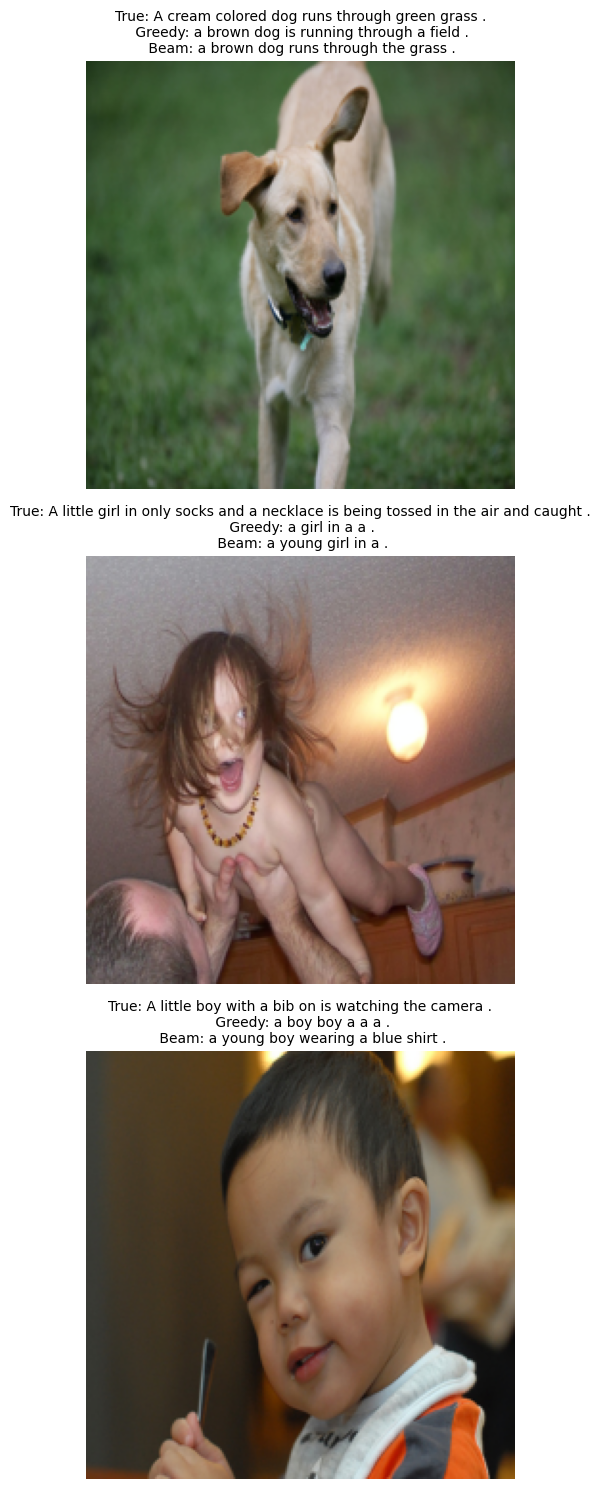

In [19]:
# Comparing Beam Vs Beam Search
# Greedy Search : Selects most probable word at each step without considering future possibilities. -> fast, simple -> useful for debugging.
# Beam Search (k=5) : Explores multiple possibilities (in this case, up to 5) at each step to find a better overall sequence.

import random
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def compare_decoding_strategies(model, test_loader, vocab, device, num_examples=3, beam_size=5, seed=None):
    """Compare greedy search and beam search predictions with random sampling """
    if seed is not None:
        random.seed(seed)

    model.eval()
    smoothie = SmoothingFunction().method4

    # Get ALL test data and select random indices for some fun samples!
    all_images = []
    all_captions = []
    for batch in test_loader:
        all_images.append(batch['image'])
        all_captions.append(batch['all_captions'])

    # Flatten the lists
    all_images = torch.cat(all_images, dim=0)
    all_captions = [cap for sublist in all_captions for cap in sublist]

    # Select random unique indices
    total_samples = len(all_images)
    selected_indices = random.sample(range(total_samples), min(num_examples, total_samples))

    # Prepare selected samples
    images = all_images[selected_indices].to(device)
    true_captions = [all_captions[i] for i in selected_indices]

    # Generate predictions
    greedy_preds = trainer.generate_captions_greedy(images)
    beam_preds = trainer.generate_captions_beam(images, beam_size=beam_size)

    # Calculate BLEU scores for evaluation
    def compute_bleu(preds):
        references = [[word_tokenize(ref.lower()) for ref in captions] for captions in true_captions]
        hypotheses = [word_tokenize(pred.lower()) for pred in preds]
        bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoothie)
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)
        return bleu1, bleu4

    greedy_bleu1, greedy_bleu4 = compute_bleu(greedy_preds)
    beam_bleu1, beam_bleu4 = compute_bleu(beam_preds)

    print(f"\n Greedy Search - BLEU-1: {greedy_bleu1:.4f}, BLEU-4: {greedy_bleu4:.4f}")
    print(f"Beam Search (k={beam_size}) - BLEU-1: {beam_bleu1:.4f}, BLEU-4: {beam_bleu4:.4f}\n")

    # Visual comparison time!
    plt.figure(figsize=(15, 5*num_examples))
    for i in range(num_examples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                      np.array([0.485, 0.456, 0.406]), 0, 1)

        plt.subplot(num_examples, 1, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_captions[i][0]}\n Greedy: {greedy_preds[i]}\n Beam: {beam_preds[i]}",
                  fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage example - will show different random samples each time
compare_decoding_strategies(trained_model, test_loader, vocab, device, num_examples=3, beam_size=5)


## **7.1 Visualizing Training Metrics**

- The model's parameters are **restored from the checkpoint with the lowest validation loss**.
- `Matplotlib` plots training and validation losses over epochs.

The curves show whether learning continues, plateaus or develops a widening gap between training and validation. Interpretation depends on the observed run, rather than assuming convergence in advance.

The plotting interface is:

```python
def plot_losses():
  raise NotImplementedError
```



 Model restored from epoch 20 with lowest validation loss.


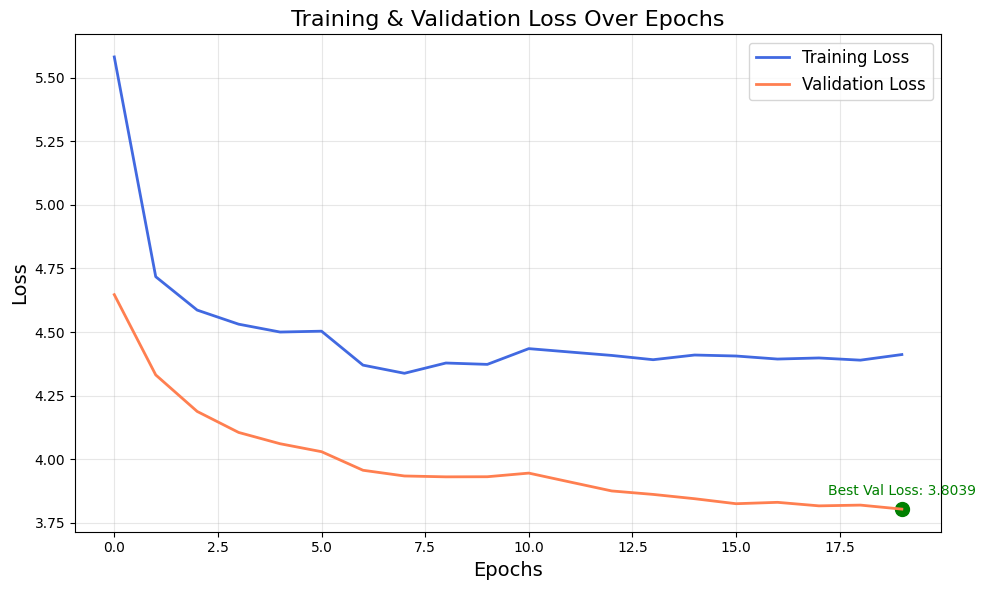


 Convergence Analysis:
- Initial Training Loss: 5.5812
- Final Training Loss: 4.4115
- Initial Validation Loss: 4.6468
- Final Validation Loss: 3.8039

 The model converged successfully.


In [20]:
import matplotlib.pyplot as plt

def plot_losses(trainer):
    """Restores the checkpoint with the lowest validation loss, as 7.1 asks,
    and plots the training and validation loss curves over epochs.

    Args:
        trainer (EnhancedImageCaptioningTrainer): The trainer object containing training history.
    """
    # The trainer keeps the lowest-validation-loss epoch.
    if trainer.best_metrics['state_dict'] is not None:
        trainer.model.load_state_dict(trainer.best_metrics['state_dict'])
        print(f"\n\033[1;32m Model restored from epoch {trainer.best_metrics['epoch'] + 1} with lowest validation loss.\033[0m")
    else:
        print("\n\033[1;31m No checkpoint found. Ensure training has been completed.\033[0m")
        return

    # Plot the training and validation loss curves
    plt.figure(figsize=(10, 6))
    plt.plot(trainer.train_loss_history, label='Training Loss', color='royalblue', linewidth=2)
    plt.plot(trainer.val_loss_history, label='Validation Loss', color='coral', linewidth=2)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title(' Training & Validation Loss Over Epochs ', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Annotate the best epoch
    best_epoch = trainer.best_metrics['epoch']
    best_val_loss = trainer.best_metrics['val_loss']
    plt.scatter(best_epoch, best_val_loss, color='green', s=100, label=f'Best Epoch: {best_epoch + 1}')
    plt.annotate(
        f"Best Val Loss: {best_val_loss:.4f}",
        (best_epoch, best_val_loss),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color='green'
    )

    plt.tight_layout()
    plt.show()

    # Analyze convergence
    if len(trainer.train_loss_history) > 1 and len(trainer.val_loss_history) > 1:
        final_train_loss = trainer.train_loss_history[-1]
        final_val_loss = trainer.val_loss_history[-1]
        initial_train_loss = trainer.train_loss_history[0]
        initial_val_loss = trainer.val_loss_history[0]

        print("\n\033[1m Convergence Analysis:\033[0m")
        print(f"- Initial Training Loss: {initial_train_loss:.4f}")
        print(f"- Final Training Loss: {final_train_loss:.4f}")
        print(f"- Initial Validation Loss: {initial_val_loss:.4f}")
        print(f"- Final Validation Loss: {final_val_loss:.4f}")

        if final_train_loss < initial_train_loss and final_val_loss < initial_val_loss:
            print("\n\033[1;32m The model converged successfully.\033[0m")
        elif final_train_loss < initial_train_loss and final_val_loss >= initial_val_loss:
            print("\n\033[1;33m The model may have overfit to the training data.\033[0m")
        else:
            print("\n\033[1;31m The model did not converge properly.\033[0m")

# `trainer` is an instance of EnhancedImageCaptioningTrainer
plot_losses(trainer)


### Reading the training curves

The two losses measure different conditions. Training loss is computed on
augmented images with a sampled reference caption, token dropout and
scheduled sampling. Validation loss uses deterministic transforms, one fixed
reference caption per image and teacher forcing. A gap between them reflects
that difference as well as any overfitting.

Convergence is read from sustained improvement in validation loss together
with the quality of the generated captions. The checkpoint is the epoch with
the lowest validation loss.

Validation BLEU uses greedy decoding, which is fast enough to run every epoch.
Final test BLEU uses beam search against all five references, so the two
numbers differ by split and by decoding strategy. Learning-rate restarts from
the cosine schedule produce visible steps in the curve.


## **7.2 Visualizing Attention Weights**

The **attention weights** are overlaid on the image to show how spatial weighting changes during caption generation. Each displayed word is paired with the map from its prediction step.

The weights describe the model's attention distribution; the `context` vector is the weighted feature representation used by the decoder. These visualizations support interpretation without establishing causal explanations.

The plotting interface is:

```python
def plot_attention():
  raise NotImplementedError
```


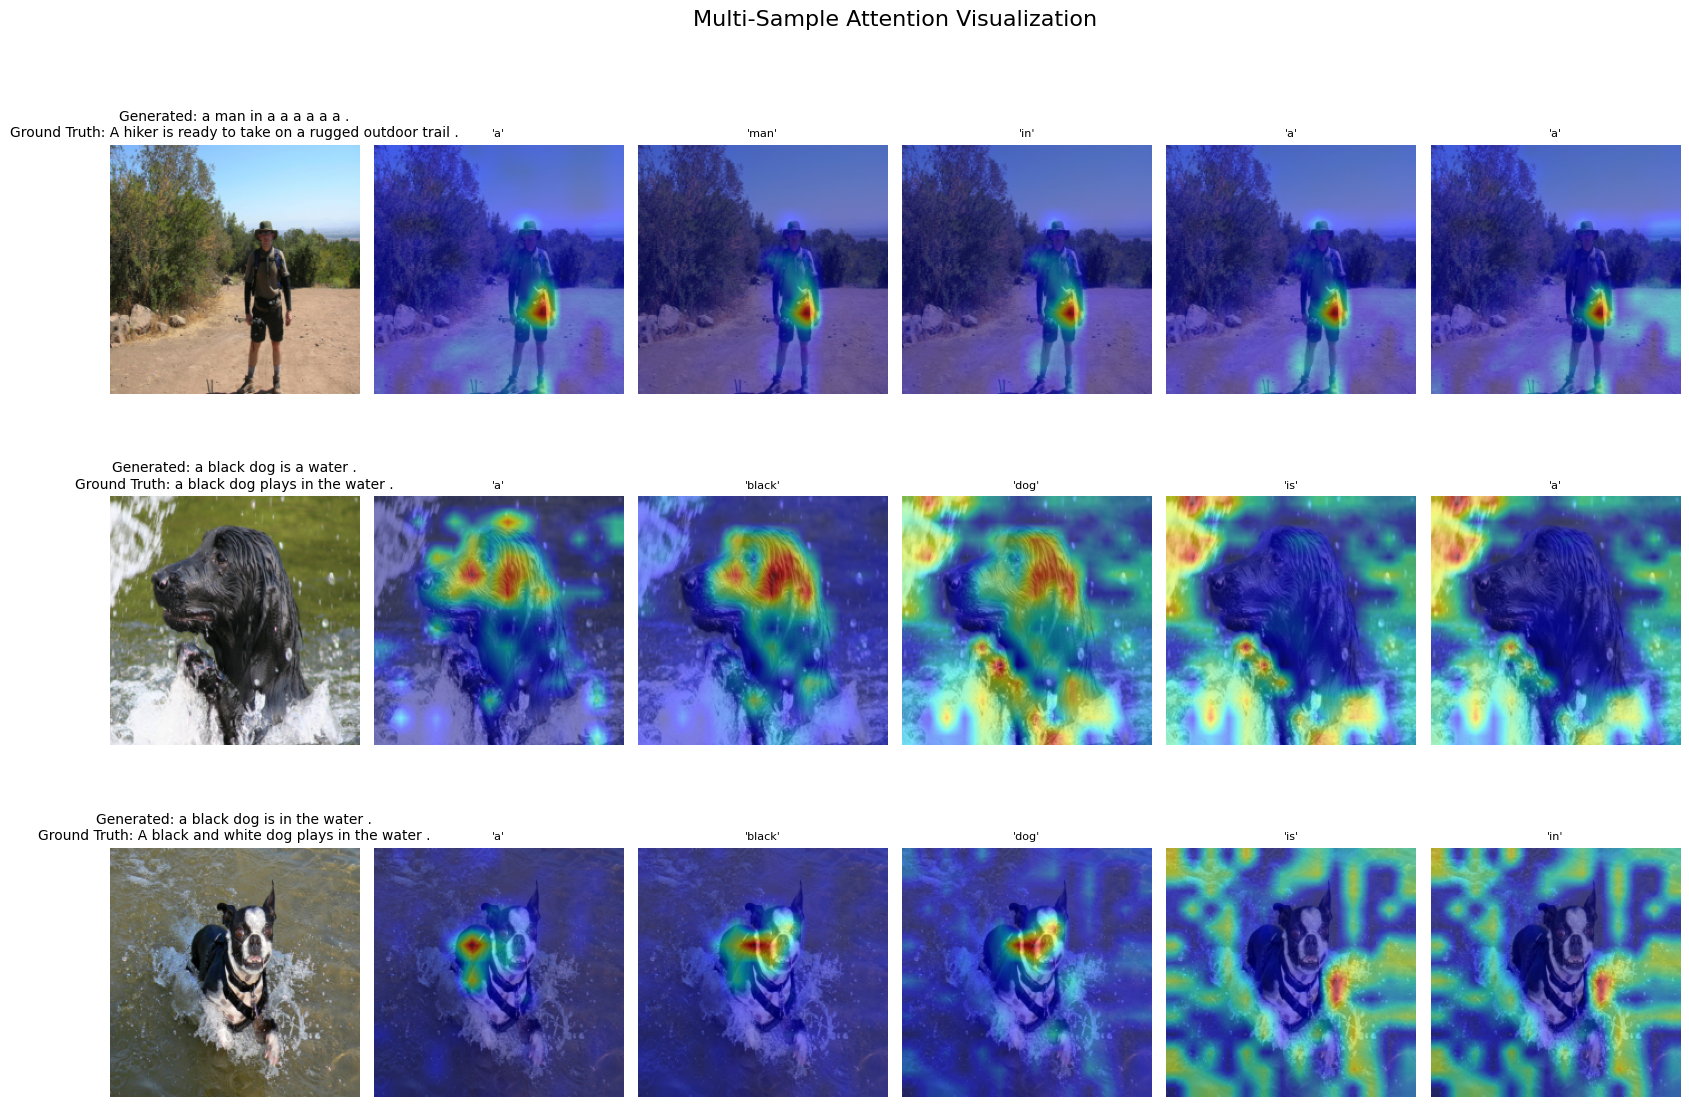

In [21]:
def plot_attention_for_samples(samples, model, vocab, device, save_path='attention_grid.png', max_len=30):
    model.eval()
    rows = len(samples)

    if not samples:
        raise ValueError("No valid images available for attention visualization.")
    cols = 5
    fig = plt.figure(figsize=(16, 4 * rows))
    gs = fig.add_gridspec(rows, cols + 1)  # +1 for the main image

    for row_idx, sample in enumerate(samples):
        image = sample['image'].unsqueeze(0).to(device)
        caption_tokens = sample['caption_tokens']
        ground_truth = sample.get('ground_truth', None)

        # Forward pass
        with torch.no_grad():
            features = model.encoder(image)
            h, c = model.decoder.init_hidden_state(features)
            inputs = torch.tensor([int(caption_tokens[0])]).to(device)
            attentions = []
            # Label each map with the word the model produced at that step.
            predicted_words = []

            for i in range(max_len):
                embeddings = model.decoder.embedding(inputs.unsqueeze(0))
                context, attn_weights = model.decoder.attention(features, h)

                # Process attention weights
                if attn_weights.dim() == 4:
                    attn_weights = attn_weights.mean(dim=1).squeeze(0)
                elif attn_weights.dim() == 3:
                    attn_weights = attn_weights.squeeze(0)

                if attn_weights.dim() == 2:
                    current_attn = attn_weights[-1]
                else:
                    current_attn = attn_weights


                # Continue with LSTM step
                context = context.unsqueeze(1)
                lstm_input = torch.cat([embeddings, context], dim=2).squeeze(1)
                h, c = model.decoder.lstm(lstm_input, (h, c))
                outputs = model.decoder.fc(h)
                predicted = outputs.argmax(dim=-1)
                inputs = predicted
                word = vocab.idx2word.get(int(predicted.item()), '<unk>')
                if word == '<eos>':
                    break
                if word not in ['<sos>', '<pad>']:
                    predicted_words.append(word)
                    attentions.append(current_attn.cpu().numpy())

        # Image preprocessing
        img_tensor = image[0].cpu().detach()
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        img_tensor = transforms.functional.normalize(
            img_tensor,
            mean=-np.array(mean)/np.array(std),
            std=1/np.array(std)
        )
        img_tensor = img_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

        # Plot original image + caption
        ax_img = fig.add_subplot(gs[row_idx, 0])
        ax_img.imshow(img_tensor)
        caption_text = " ".join(predicted_words)
        title = f"Generated: {caption_text}"
        if ground_truth:
            title += f"\nGround Truth: {ground_truth}"
        ax_img.set_title(title, fontsize=10)
        ax_img.axis('off')

        # Plot attention maps for each word
        for col_idx, (word, attn) in enumerate(zip(predicted_words[:cols], attentions[:cols])):
            ax = fig.add_subplot(gs[row_idx, col_idx + 1])  # +1 to skip image column

            # Infer grid size from attention vector length
            num_patches = len(attn)
            grid_side = int(np.sqrt(num_patches))

            try:
                attn_map = attn.reshape(grid_side, grid_side)
            except:
                # Fallback to linear arrangement if not perfect square
                attn_map = attn.reshape(1, -1)

            # Resize attention map to match image size
            attn_resized = transforms.functional.resize(
                torch.from_numpy(attn_map).unsqueeze(0).unsqueeze(0),  # [1, 1, H, W]
                img_tensor.shape[:2],
                interpolation=transforms.InterpolationMode.BILINEAR
            ).squeeze().numpy()

            ax.imshow(img_tensor)
            ax.imshow(attn_resized, cmap='jet', alpha=0.5)
            ax.set_title(f"'{word}'", fontsize=8)
            ax.axis('off')

    plt.suptitle("Multi-Sample Attention Visualization", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# The dataset already yields the dictionaries the plot wants.
samples = []
for i in range(3):
    sample = test_dataset[i]
    if sample is None:
        continue
    sample = dict(sample)
    sample['ground_truth'] = sample['original_caption']
    samples.append(sample)

#Call the plotting function
plot_attention_for_samples(samples, trained_model, vocab, device=device)


## **7.3 Running Inference on the Image Captioning Model**

The **custom-trained image captioning model** generates captions for the held-out test images. Evaluation uses **[BLEU](https://pytorch.org/text/stable/data_metrics.html)** at four n-gram orders: **BLEU-1, BLEU-2, BLEU-3 and BLEU-4**.

Final test evaluation uses **beam search decoding**, while greedy decoding provides faster validation monitoring during training.  

[Beam Search](https://d2l.ai/chapter_recurrent-modern/beam-search.html) is a more sophisticated decoding algorithm that **considers multiple possible caption sequences at each time step instead of selecting the most probable word at every step (greedy decoding)**. It maintains a fixed number of candidate sequences (beam width) and expands them based on their cumulative probabilities, ultimately selecting the **most likely complete caption**.  

Using beam search can lead to **more fluent and accurate captions** by avoiding suboptimal word choices that greedy decoding might make.

```python
def test_model()
  raise NotImplementedError
```


 Running Inference on Test Set with Beam Search...



 BLEU Scores on Test Set:
BLEU-1: 0.6557
BLEU-2: 0.4504
BLEU-3: 0.3063
BLEU-4: 0.2036

 Final BLEU Scores:
BLEU1: 0.6557
BLEU2: 0.4504
BLEU3: 0.3063
BLEU4: 0.2036


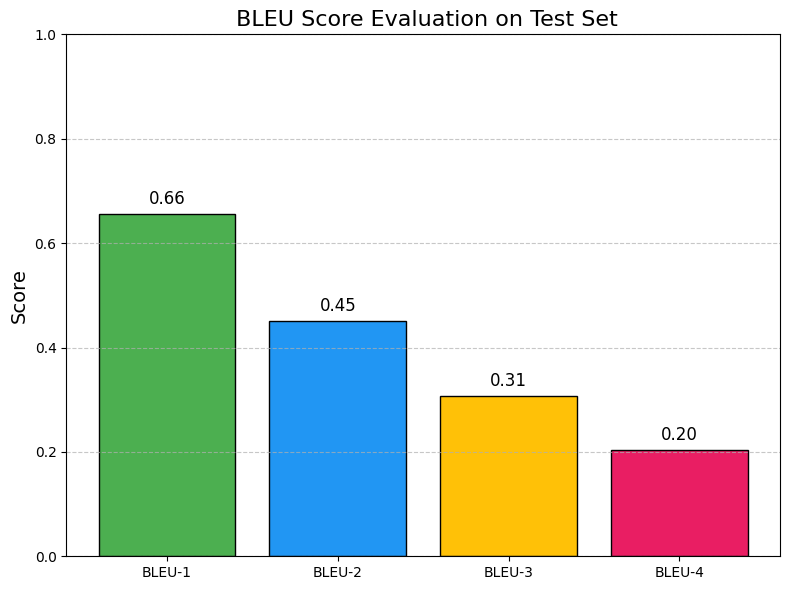

In [22]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import matplotlib.pyplot as plt

def test_model(trainer, test_loader, beam_size=5):
    """
     7.3 Running Inference on the Image Captioning Model

    Pass test images through the custom-trained image captioning model, then evaluate its performance on the test set.
    Use the BLEU score as the evaluation metric, implementing BLEU-1, BLEU-2, BLEU-3, and BLEU-4.

     Beam search decoding is used (beam size = 5) instead of greedy decoding for better caption quality.
    """

    print("\n\033[1m Running Inference on Test Set with Beam Search...\033[0m")

    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method4

    # Set model to evaluation mode
    trainer.model.eval()

    with torch.inference_mode():
        for batch in tqdm(test_loader, desc="Processing Test Samples", leave=False):
            images = batch['image'].to(trainer.device)
            captions = batch['all_captions']

            # Generate captions using beam search decoding
            generated_captions = trainer.generate_captions_beam(images, beam_size=beam_size)

            for i, caption in enumerate(captions):
                refs = [word_tokenize(ref.lower()) for ref in caption]  # All references
                hyp = word_tokenize(generated_captions[i].lower())  # Tokenized hypothesis
                references.append(refs)
                hypotheses.append(hyp)

    # Calculate BLEU scores
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

    # Print BLEU scores
    print("\n\033[1m BLEU Scores on Test Set:\033[0m")
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-3: {bleu3:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

    return {
        'bleu1': bleu1,
        'bleu2': bleu2,
        'bleu3': bleu3,
        'bleu4': bleu4
    }

# --- Call the test_model function ---
test_results = test_model(trainer, test_loader, beam_size=5)

# --- Print the Final BLEU Scores ---
print("\n Final BLEU Scores:")
for k, v in test_results.items():
    print(f"{k.upper()}: {v:.4f}")

# Plot BLEU Scores Bar Chart
def plot_bleu_scores(results):
    """Plot BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores nicely.
    """
    labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    scores = [results['bleu1'], results['bleu2'], results['bleu3'], results['bleu4']]
    colors = ['#4CAF50', '#2196F3', '#FFC107', '#E91E63'] # Fancy colors

    plt.figure(figsize=(8,6))
    bars = plt.bar(labels, scores, color=colors, edgecolor='black')
    plt.title(' BLEU Score Evaluation on Test Set', fontsize=16)
    plt.ylabel('Score', fontsize=14)
    plt.ylim(0, 1.0)

    # Annotate bars with actual score values
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the plot function
plot_bleu_scores(test_results)


## **8. Loading an Existing Image Captioning Model**

The comparison uses **pre-trained BLIP**. The two model families below provide context for this choice:

1. **BLIP (Bootstrapping Language-Image Pre-training):** BLIP is a versatile vision-language pre-training framework that excels in both understanding and generation tasks. It effectively utilizes noisy web data by generating and filtering synthetic captions, achieving SOTA results in image captioning. Pre-trained models and code are available on [GitHub](https://github.com/salesforce/BLIP) and the [Hugging Face Model Hub](https://huggingface.co/Salesforce/blip-image-captioning-base).

2. **ViT-GPT2 Image Captioning Model:** This model combines a Vision Transformer (ViT) as the encoder and GPT-2 as the decoder, effectively connecting visual inputs with text generation. A fine-tuned version on the Flickr8k dataset is accessible on the [Hugging Face Model Hub](https://huggingface.co/NourFakih/image-captioning-Vit-GPT2-Flickr8k).

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.88GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

BLIP model loaded successfully.


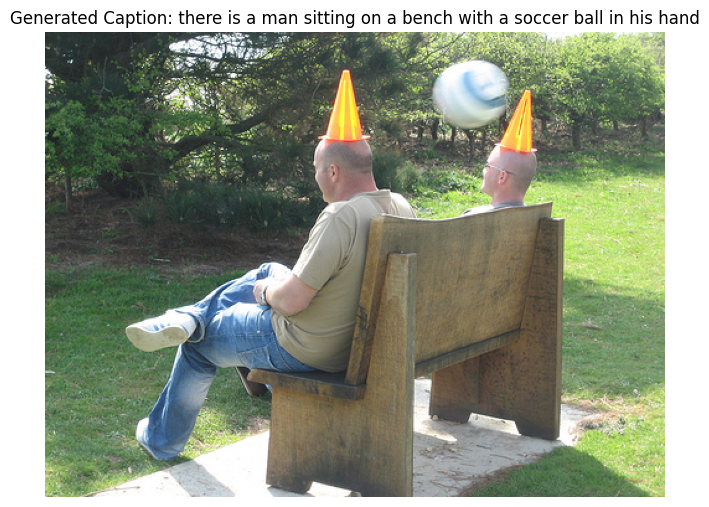

Image: 222878446_32c6fc4bc9.jpg
Generated Caption: there is a man sitting on a bench with a soccer ball in his hand


In [23]:
# Imports
import os
import random
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import matplotlib.pyplot as plt  # For displaying images

# Load Model and Processor
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
pretrained_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)

# Indicate that the BLIP model is loaded
print("BLIP model loaded successfully.")

# Path to your image folder. DATA_DIR is resolved in setup, so this works
# whether the dataset sits in the project folder, in Drive or on a runtime.
image_folder = DATA_DIR / 'Images'

# Get all image files (they're .jpg or .jpeg files)
image_files = [f.name for f in image_folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg')]

# Randomly choose one image
random_image = random.choice(image_files)
image_path = image_folder / random_image

# Load the randomly selected image
image = Image.open(image_path).convert('RGB')

# Prepare Inputs
inputs = processor(images=image, return_tensors="pt").to(device)

# Generate Caption
with torch.no_grad():
    output = pretrained_model.generate(**inputs)

# Decode and Print Caption
caption = processor.decode(output[0], skip_special_tokens=True)

# Display the Image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.title(f"Generated Caption: {caption}")  # Title with caption
plt.show()

# Print the Caption and Image Info
print(f"Image: {random_image}")
print(f"Generated Caption: {caption}")


## **9. Evaluating the Existing Image Captioning Model**

BLIP is evaluated with the **same BLEU metrics, tokenization and reference captions** as the custom model, providing a consistent basis for the test-set comparison.

In [24]:
!pip install pycocoevalcap -q  # Installs the pycocoevalcap package () evaluating image captioning models)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 9.5 MB/s eta 0:00:00:00:0100:01


In [25]:
!pip install colorama -q  # Installs the colorama package (colored text to output)
!pip install tabulate -q  # Installs the tabulate package  (creating and formatting tables)

In [26]:
# Evaluation Function
import sys
import torch
from tqdm.auto import tqdm  # <-- smoother in Colab (important!)
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from colorama import Fore, Style
from tabulate import tabulate

def evaluate_pretrained_blip(test_loader, processor, pretrained_model, device="cuda"):
    """Evaluate the pre-trained BLIP model on the test set using BLEU scores.
    """
    print(f"\n{Style.BRIGHT} Evaluating Pre-Trained BLIP Model on Test Set...{Style.RESET_ALL}")

    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method4

    pretrained_model.eval()
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Processing Test Samples", leave=True, file=sys.stdout):
            images = batch['image']
            original_captions = batch['all_captions']

            # Undo the ImageNet normalisation channel by channel, matching the
            # model comparison, then let the processor do its own scaling.
            denorm = images.cpu() * torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            denorm = denorm + torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            images_pil = [transforms.ToPILImage()(img.clamp(0, 1)) for img in denorm]

            inputs = processor(
                images=images_pil,
                return_tensors="pt"
            ).to(device)

            outputs = pretrained_model.generate(
                **inputs,
                num_beams=5,
                max_new_tokens=20,
                no_repeat_ngram_size=2
            )

            preds = processor.batch_decode(outputs, skip_special_tokens=True)

            for pred_caption, true_captions in zip(preds, original_captions):
                refs = [word_tokenize(t.lower()) for t in true_captions]
                # Tokenize the hypothesis like the references, or BLIP's
                # punctuation stays glued to words and misses every n-gram.
                hyp = word_tokenize(pred_caption.lower())
                references.append(refs)
                hypotheses.append(hyp)

    # Calculate BLEU scores
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    avg_bleu = (bleu1 + bleu2 + bleu3 + bleu4) / 4

    # Leaderboard Table
    table = [
        ["BLEU-1", f"{bleu1:.4f}"],
        ["BLEU-2", f"{bleu2:.4f}"],
        ["BLEU-3", f"{bleu3:.4f}"],
        ["BLEU-4", f"{bleu4:.4f}"],
        ["Avg BLEU", f"{avg_bleu:.4f}"]
    ]

    print(f"\n{Style.BRIGHT} Evaluation Metrics Leaderboard:{Style.RESET_ALL}")
    print(Fore.CYAN + tabulate(table, headers=["Metric", "Score"], tablefmt="fancy_grid") + Style.RESET_ALL)

    # Fun final feedback
    if avg_bleu > 0.6:
        print(f"\n{Fore.GREEN} Model is crushing it! Average BLEU: {avg_bleu:.4f}{Style.RESET_ALL}")
    elif avg_bleu > 0.4:
        print(f"\n{Fore.YELLOW} Solid performance! Room for more awesomeness! Average BLEU: {avg_bleu:.4f}{Style.RESET_ALL}")
    else:
        print(f"\n{Fore.RED} Keep improving! You're almost there! Average BLEU: {avg_bleu:.4f}{Style.RESET_ALL}")

    return {
        'bleu1': bleu1,
        'bleu2': bleu2,
        'bleu3': bleu3,
        'bleu4': bleu4,
        'avg_bleu': avg_bleu
    }

# Example usage
if __name__ == "__main__":
    # test_loader is already defined
    metrics = evaluate_pretrained_blip(test_loader, processor, pretrained_model, device=device)
    print("\n Final BLEU Scores:", metrics)



 Evaluating Pre-Trained BLIP Model on Test Set...


Processing Test Samples:   0%|          | 0/38 [00:00<?, ?it/s]


 Evaluation Metrics Leaderboard:
╒══════════╤═════════╕
│ Metric   │   Score │
╞══════════╪═════════╡
│ BLEU-1   │  0.6162 │
├──────────┼─────────┤
│ BLEU-2   │  0.4427 │
├──────────┼─────────┤
│ BLEU-3   │  0.3057 │
├──────────┼─────────┤
│ BLEU-4   │  0.208  │
├──────────┼─────────┤
│ Avg BLEU │  0.3931 │
╘══════════╧═════════╛

 Keep improving! You're almost there! Average BLEU: 0.3931

 Final BLEU Scores: {'bleu1': 0.616211540837761, 'bleu2': 0.4427103753629551, 'bleu3': 0.30567938958394786, 'bleu4': 0.2079977136410441, 'avg_bleu': 0.39314975485642695}


## **10. Comparing the Two Models**

The comparison reports **BLEU-1, BLEU-2, BLEU-3 and BLEU-4** for both models and displays their predictions on the **same batch of test images**.

Scores and examples are interpreted together, considering differences in architecture, attention and training history. Observed strengths and failure cases motivate possible follow-up experiments for the custom model.


> **Comparison focus:** Reference overlap, visual accuracy and representative caption errors.



 Evaluating Models...



 Performance Comparison:
+----------+----------------+--------------+--------------+
| Metric   |   Custom Model |   BLIP Model |   Difference |
+==========+================+==============+==============+
| BLEU-1   |         0.6557 |       0.6162 |      -0.0395 |
+----------+----------------+--------------+--------------+
| BLEU-2   |         0.4504 |       0.4427 |      -0.0077 |
+----------+----------------+--------------+--------------+
| BLEU-3   |         0.3063 |       0.3057 |      -0.0007 |
+----------+----------------+--------------+--------------+
| BLEU-4   |         0.2036 |       0.208  |       0.0044 |
+----------+----------------+--------------+--------------+
| Avg BLEU |         0.404  |       0.3931 |      -0.0109 |
+----------+----------------+--------------+--------------+

 Visual Predictions:


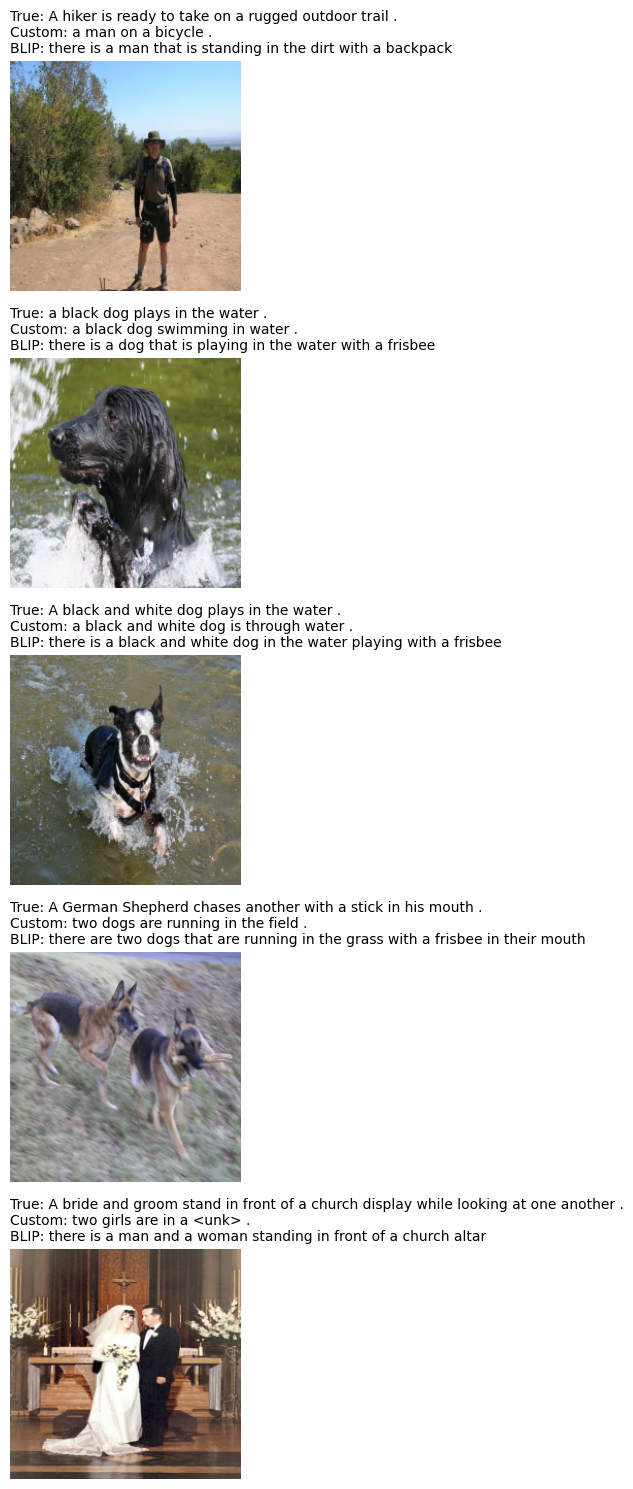

In [27]:
# Import necessary libraries
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from tabulate import tabulate
import numpy as np
import torchvision.transforms as transforms
from PIL import Image

class ModelComparison:
    def __init__(self, custom_trainer, blip_model, processor, vocab, device='cuda'):
        self.custom_trainer = custom_trainer
        self.blip_model = blip_model.to(device)
        self.processor = processor
        self.vocab = vocab
        self.device = device

    def _normalize_images(self, images):
        """Normalize images for BLIP processing using processor"""
        images_pil = []
        for img in images:
            img = img.cpu()
            # Denormalize with ImageNet normalization
            img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            img = img.clamp(0, 1)
            img = transforms.ToPILImage()(img)
            images_pil.append(img)
        processed = self.processor(images=images_pil, return_tensors="pt").to(self.device)
        return processed['pixel_values']

    def _evaluate_model(self, model_type, val_loader):
        references = []
        hypotheses = []
        smoothie = SmoothingFunction().method4

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Evaluating {model_type}", leave=False):
                images = batch['image'].to(self.device)
                true_captions = batch['all_captions']

                if model_type == 'Custom':
                    pred_captions = self.custom_trainer.generate_captions_beam(images, beam_size=5)
                else:  # BLIP
                    norm_images = self._normalize_images(images)
                    inputs = {'pixel_values': norm_images}
                    outputs = self.blip_model.generate(
                        **inputs,
                        num_beams=5,
                        max_new_tokens=20,
                        no_repeat_ngram_size=2
                    )
                    pred_captions = self.processor.batch_decode(outputs, skip_special_tokens=True)

                for pred, refs in zip(pred_captions, true_captions):
                    ref_tokens = [word_tokenize(r.lower()) for r in refs]
                    hyp_tokens = word_tokenize(pred.lower())
                    references.append(ref_tokens)
                    hypotheses.append(hyp_tokens)

        bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
        bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

        return {
            'bleu1': bleu1,
            'bleu2': bleu2,
            'bleu3': bleu3,
            'bleu4': bleu4,
            'avg_bleu': (bleu1 + bleu2 + bleu3 + bleu4) / 4
        }

    def _visualize_comparison(self, images, true_captions, custom_preds, blip_preds, num_examples=5):
        plt.figure(figsize=(15, 3 * num_examples))

        for i in range(min(num_examples, len(images))):
            img = images[i].cpu().numpy()
            img = img * np.array([0.229, 0.224, 0.225])[:, None, None]
            img = img + np.array([0.485, 0.456, 0.406])[:, None, None]
            img = np.clip(img, 0, 1)
            img = img.transpose(1, 2, 0)  # CHW -> HWC

            plt.subplot(num_examples, 1, i + 1)
            plt.imshow(img)
            plt.title(
                f"True: {true_captions[i]}\n"
                f"Custom: {custom_preds[i]}\n"
                f"BLIP: {blip_preds[i]}",
                loc='left',
                fontsize=10
            )
            plt.axis('off')

        plt.tight_layout()
        plt.show()

    def compare_models(self, val_loader, num_examples=3):
        print("\n Evaluating Models...")
        custom_metrics = self._evaluate_model('Custom', val_loader)
        blip_metrics = self._evaluate_model('BLIP', val_loader)

        print("\n Performance Comparison:")
        table = [
            ["Metric", "Custom Model", "BLIP Model", "Difference"],
            ["BLEU-1", f"{custom_metrics['bleu1']:.4f}", f"{blip_metrics['bleu1']:.4f}",
             f"{blip_metrics['bleu1'] - custom_metrics['bleu1']:+.4f}"],
            ["BLEU-2", f"{custom_metrics['bleu2']:.4f}", f"{blip_metrics['bleu2']:.4f}",
             f"{blip_metrics['bleu2'] - custom_metrics['bleu2']:+.4f}"],
            ["BLEU-3", f"{custom_metrics['bleu3']:.4f}", f"{blip_metrics['bleu3']:.4f}",
             f"{blip_metrics['bleu3'] - custom_metrics['bleu3']:+.4f}"],
            ["BLEU-4", f"{custom_metrics['bleu4']:.4f}", f"{blip_metrics['bleu4']:.4f}",
             f"{blip_metrics['bleu4'] - custom_metrics['bleu4']:+.4f}"],
            ["Avg BLEU", f"{custom_metrics['avg_bleu']:.4f}", f"{blip_metrics['avg_bleu']:.4f}",
             f"{blip_metrics['avg_bleu'] - custom_metrics['avg_bleu']:+.4f}"]
        ]
        print(tabulate(table, headers="firstrow", tablefmt="grid"))

        print("\n Visual Predictions:")
        batch = next(iter(val_loader))
        images = batch['image'].to(self.device)
        true_captions = batch['original_caption']

        # Custom model predictions
        custom_preds = self.custom_trainer.generate_captions_beam(images, beam_size=5)

        # BLIP predictions
        images_pil = []
        for img in images:
            img = img.cpu()
            # Denormalize with ImageNet normalization
            img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            img = img.clamp(0, 1)
            img = transforms.ToPILImage()(img)
            images_pil.append(img)

        inputs = self.processor(images=images_pil, return_tensors="pt").to(self.device)
        blip_outputs = self.blip_model.generate(
            **inputs,
            num_beams=5,
            max_new_tokens=20,
            no_repeat_ngram_size=2
        )
        blip_preds = self.processor.batch_decode(blip_outputs, skip_special_tokens=True)

        self._visualize_comparison(images, true_captions, custom_preds, blip_preds, num_examples)

# Example Usage
if __name__ == "__main__":
    # - trained_model (your trained EncoderDecoder model)
    # - pretrained_model (pre-trained BLIP model)
    # - processor (BLIP processor)
    # - vocab (vocabulary object)
    # - val_loader (validation data loader)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize the trainer for your custom model
    custom_trainer = EnhancedImageCaptioningTrainer(
        model=trained_model,
        train_loader=None,  # Not needed for evaluation
        val_loader=val_loader,
        test_loader=test_loader,
        vocab=vocab,
        device=device,
    )

    # Initialize the comparison tool
    comparison_tool = ModelComparison(
        custom_trainer=custom_trainer,
        blip_model=pretrained_model,
        processor=processor,
        vocab=vocab,
        device=device
    )

    # Score on the held-out test split; val_loader already picked the
    # checkpoint, so comparing there would reuse seen data.
    comparison_tool.compare_models(val_loader=test_loader, num_examples=5)


### Comparing the custom model with BLIP

Both models are scored on the same held-out test images, against all
available reference captions, with the same BLEU tokenization and smoothing.
BLIP is evaluated with its pretrained weights; the custom model learns
Flickr8k from a pretrained ViT encoder and an LSTM decoder. The comparison is
therefore between two systems with different training histories rather than
between two architectures trained alike.

The reading combines BLEU-1 through BLEU-4 with the captions themselves,
looking at object identity, actions, relationships and any detail the image
does not support. BLEU measures overlap with the references, so a higher
score shows closer agreement with how the reference writers phrased things.


### Interpreting the results and limitations

The custom encoder exposes 196 spatial patch features and fine-tunes its last four transformer blocks. The LSTM attends to these features when predicting the next token. Attention plots pair generated words with their corresponding spatial weights; they are descriptive visualizations, not proof that a region caused a prediction.

The model is trained with random caption selection, image augmentation, token dropout, label smoothing and scheduled sampling. These choices may help generalization but their benefit requires controlled comparisons. Some augmentations can also remove or alter details named in a caption, so the examples help distinguish preprocessing effects from model limitations.

The best checkpoint minimizes validation loss. Greedy validation BLEU provides a faster progress signal, while final test evaluation uses beam search. BLIP's standalone evaluation and comparison both use five beams, at most 20 new tokens and a block on repeated bigrams. These decoding settings are part of the reported evaluation protocol.

Follow-up experiments worth running include comparing a frozen encoder against the fine-tuned one, varying the decoding settings, and adding a semantic metric or a documented human review.

Checkpoints contain vocabulary mappings and experiment configuration. Resume rejects missing or incompatible metadata rather than silently assigning weights to different words. Older checkpoints should be kept separately. Epoch-level resume restores model and optimizer state, but does not guarantee a bit-for-bit identical trajectory across runtime resets or hardware changes.
